## packages

In [369]:
from datetime import datetime
from datetime import timedelta
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
import warnings
from dateutil.relativedelta import relativedelta
from dateutil import parser
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")

## data prep

In [371]:
# Function call to process the tradewed data file
def data_preprocess(filepath):
    rawdata = pd.read_csv(filepath)
    rawdata = rawdata.loc[rawdata['ACCEPTEDVOL'] != 0] # Ignore trade stamps with zero volume
    # Remove BILLs , STRIPs and TRSY FRN data to skip the computation from yield to price for Bills and negative spreads for Strips + Treasury FRN
    substring = 'Bill'
    substring2 = 'Strip'
    substring3 = 'TRSY FRN'
    filter = rawdata['MATURITY_RANGE'].str.contains(substring)
    rawdata = rawdata[~filter]
    filter2 = rawdata['MATURITY_RANGE'].str.contains(substring2)
    rawdata = rawdata[~filter2]
    filter3 = rawdata['MATURITY_RANGE'].str.contains(substring3)
    rawdata = rawdata[~filter3]
    rawdata = rawdata.loc[rawdata['TRADETYPE'] == 'OUTRIGHT'] # Only consider outright trades
    rawdata.reset_index(inplace=True)
    # Convert TRADETIME , MATURITY DATE and TRADE DATE to datetime and assign new index
    tradetime = []
    tradedate = []
    maturitydate = []
    for i in range(rawdata.shape[0]):
        tradetime.append(datetime.datetime.strptime(rawdata['TRADETIME'].iloc[i].rstrip(' Z'), "%Y-%m-%d %H:%M:%S.%f"))
        tradedate.append(datetime.datetime.strptime(rawdata['TRADEDATE'].iloc[i], '%m/%d/%y'))
        maturitydate.append(datetime.datetime.strptime(rawdata['MATURITY_DATE'].iloc[i], '%m/%d/%y'))
    rawdata['TIMESTAMP'] = tradetime
    rawdata['TRADEDATE'] = tradedate
    rawdata['MATURITY_DATE'] = maturitydate
    rawdata.set_index('TIMESTAMP', inplace= True)
    rawdata.sort_index(inplace=True)
    return rawdata

In [372]:
tw1 = data_preprocess('/Users/jiangzixuan/Desktop/Blockhouse/Blockhouse Data 1.csv')
tw2 = data_preprocess('/Users/jiangzixuan/Desktop/Blockhouse/Blockhouse Data 2.csv')
tw3 = data_preprocess('/Users/jiangzixuan/Desktop/Blockhouse/Blockhouse Data 3.csv')
tw4 = data_preprocess('/Users/jiangzixuan/Desktop/Blockhouse/Blockhouse Data 4.csv')
rawdata = pd.concat([tw1, tw2, tw3, tw4], axis =0)

In [373]:
rawdata.columns

Index(['index', 'TRADEDATE', 'DEALER', 'DEALERCOUNT', 'ACCEPTED',
       'SEEN_INQUIRY', 'ACCEPTEDVOL', 'SEENVOLUME', 'PRICE', 'TRADETIME',
       'INSTRUMENT', 'INSTRUMENT_DESC', 'MATURITY_DATE', 'MATURITY_RANGE',
       'COUPON_RATE', 'SIDE', 'COMP_ASK', 'COMP_BID', 'PROTOCOL', 'TRADETYPE',
       'SOURCE'],
      dtype='object')

In [374]:
rawdata.head(5)

,index,TRADEDATE,DEALER,DEALERCOUNT,ACCEPTED,SEEN_INQUIRY,ACCEPTEDVOL,SEENVOLUME,PRICE,TRADETIME,...,INSTRUMENT_DESC,MATURITY_DATE,MATURITY_RANGE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,PROTOCOL,TRADETYPE,SOURCE
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-10-02 06:47:43,47059,2023-10-02,D69,5,1,1,1100.90,1100.90,99.761887,2023-10-02 06:47:43.000 Z,...,"T 4 5/8 <MD2Y,2462045> 5yr",2028-09-30,Note 3.5 - 5.5 Year,4.625,BUY,99.769531,99.753906,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,19829,2023-10-02,D38,5,1,1,3939.00,3939.00,99.691574,2023-10-02 06:47:43.000 Z,...,"T 5 <MD2Y,2460919>",2025-08-31,Note 1.5 - 3.5 Year,5.000,BUY,99.703125,99.691406,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,50786,2023-10-02,D28,5,1,1,297.95,297.95,89.461106,2023-10-02 06:47:43.000 Z,...,"T 1 1/8 <MD2Y,2461345>",2026-10-31,Note 1.5 - 3.5 Year,1.125,BUY,89.488281,89.433594,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,24582,2023-10-02,D38,5,1,1,676.70,676.70,90.133013,2023-10-02 06:47:43.000 Z,...,"T 4 1/8 <MD2Y,2471130> 30yr",2053-08-15,Note >10 Year,4.125,BUY,90.160156,90.128906,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,57986,2023-10-02,D11,5,1,1,176.75,176.75,60.906450,2023-10-02 06:47:43.000 Z,...,"T 2 1/4 <MD2Y,2470583>",2052-02-15,Note >10 Year,2.250,BUY,60.960938,60.882812,REG List,OUTRIGHT,TW


In [375]:
filtered_rawdata = rawdata[['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE','MATURITY_DATE', 'TRADEDATE',"COUPON_RATE",'SIDE','COMP_ASK','COMP_BID']].copy()
filtered_rawdata.head()

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID
TIMESTAMP,,,,,,,,,,,
2023-10-02 06:47:43,D69,1100.90,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906
2023-10-02 06:47:43,D38,3939.00,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406
2023-10-02 06:47:43,D28,297.95,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594
2023-10-02 06:47:43,D38,676.70,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906
2023-10-02 06:47:43,D11,176.75,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812


In [376]:
filtered_rawdata.shape

(50741, 11)

In [377]:
filtered_rawdata['SIGN'] = filtered_rawdata['SIDE'].apply(lambda x: 1 if x == 'BUY' else -1)
filtered_rawdata['ACCEPTEDVOL'] = filtered_rawdata['ACCEPTEDVOL'] * 10
filtered_rawdata['SIGNED_VOLUME'] = filtered_rawdata['ACCEPTEDVOL'] * filtered_rawdata['SIGN']
filtered_rawdata

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME
TIMESTAMP,,,,,,,,,,,,,
2023-10-02 06:47:43,D69,11009.0,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906,1,11009.0
2023-10-02 06:47:43,D38,39390.0,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406,1,39390.0
2023-10-02 06:47:43,D28,2979.5,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,1,2979.5
2023-10-02 06:47:43,D38,6767.0,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906,1,6767.0
2023-10-02 06:47:43,D11,1767.5,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812,1,1767.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:51:46,D50,202000.0,97.605301,9128283J7,Note 0 - 1.5 Year,2024-11-30,2023-12-29,2.125,SELL,97.640625,97.585938,-1,-202000.0
2023-12-29 13:51:46,D50,121200.0,95.769699,9128284V9,Note 3.5 - 5.5 Year,2028-08-15,2023-12-29,2.875,BUY,95.820312,95.726562,1,121200.0
2023-12-29 13:51:46,D28,252500.0,97.574051,9128283P3,Note 0 - 1.5 Year,2024-12-31,2023-12-29,2.250,SELL,97.605469,97.542969,-1,-252500.0


In [378]:
# Calculate years to maturity
ytm = []
for i in range(0,rawdata.shape[0]):
    ytm.append(relativedelta(filtered_rawdata['MATURITY_DATE'].iloc[i],filtered_rawdata['TRADEDATE'].iloc[i]).years)
filtered_rawdata['Years to Maturity'] = ytm
# calculate spreads
filtered_rawdata['Spread'] = (filtered_rawdata['COMP_ASK'] - filtered_rawdata['COMP_BID'])/2

In [379]:
filtered_rawdata['MATURITY_RANGE'].unique()

array(['Note 3.5 - 5.5 Year', 'Note 1.5 - 3.5 Year', 'Note >10 Year',
       'Note 5.5 - 10 Year', 'Note 0 - 1.5 Year', 'TIPS 0 - 5 year',
       'TIPS 5 - 10 year', 'TIPS > 10 year'], dtype=object)

In [380]:
filtered_rawdata

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME,Years to Maturity,Spread
TIMESTAMP,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D69,11009.0,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906,1,11009.0,4,0.007812
2023-10-02 06:47:43,D38,39390.0,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406,1,39390.0,1,0.005859
2023-10-02 06:47:43,D28,2979.5,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,1,2979.5,3,0.027344
2023-10-02 06:47:43,D38,6767.0,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906,1,6767.0,29,0.015625
2023-10-02 06:47:43,D11,1767.5,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812,1,1767.5,28,0.039062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:51:46,D50,202000.0,97.605301,9128283J7,Note 0 - 1.5 Year,2024-11-30,2023-12-29,2.125,SELL,97.640625,97.585938,-1,-202000.0,0,0.027344
2023-12-29 13:51:46,D50,121200.0,95.769699,9128284V9,Note 3.5 - 5.5 Year,2028-08-15,2023-12-29,2.875,BUY,95.820312,95.726562,1,121200.0,4,0.046875
2023-12-29 13:51:46,D28,252500.0,97.574051,9128283P3,Note 0 - 1.5 Year,2024-12-31,2023-12-29,2.250,SELL,97.605469,97.542969,-1,-252500.0,1,0.031250


## Parameter for Price Impact Model: daily_vol, adv, beta

In [382]:
filtered_rawdata.MATURITY_RANGE.value_counts()

Note 1.5 - 3.5 Year    12244
Note 0 - 1.5 Year       9955
Note >10 Year           8946
Note 5.5 - 10 Year      8760
Note 3.5 - 5.5 Year     7661
TIPS 0 - 5 year         1620
TIPS > 10 year           782
TIPS 5 - 10 year         773
Name: MATURITY_RANGE, dtype: int64

## select one maturity data

In [717]:
group1 = filtered_rawdata[filtered_rawdata['MATURITY_RANGE'] == 'Note 1.5 - 3.5 Year']
group2 = filtered_rawdata[filtered_rawdata['MATURITY_RANGE'] == 'Note 0 - 1.5 Year']
group3 = filtered_rawdata[filtered_rawdata['MATURITY_RANGE'] == 'Note 3.5 - 5.5 Year']
group4 = filtered_rawdata[filtered_rawdata['MATURITY_RANGE'] == 'Note 5.5 - 10 Year']
group5 = filtered_rawdata[filtered_rawdata['MATURITY_RANGE'] == 'Note >10 Year']

In [385]:
group1['TRADEDATE'] = pd.to_datetime(group1['TRADEDATE'])

# Group by 'TRADEDATE' and calculate the daily volatility as the standard deviation of 'PRICE'
daily_volatility = group1.groupby('TRADEDATE')['PRICE'].std()

# Map the daily volatility back to the original DataFrame
group1['Daily_Volatility'] = group1['TRADEDATE'].map(daily_volatility)

## daily volatility

In [387]:
group1.Daily_Volatility

TIMESTAMP
2023-10-02 06:47:43    3.636997
2023-10-02 06:47:43    3.636997
2023-10-02 06:50:42    3.636997
2023-10-02 07:46:44    3.636997
2023-10-02 08:22:38    3.636997
                         ...   
2023-12-29 13:50:21    3.605377
2023-12-29 13:50:21    3.605377
2023-12-29 13:50:21    3.605377
2023-12-29 13:51:07    3.605377
2023-12-29 13:51:07    3.605377
Name: Daily_Volatility, Length: 12244, dtype: float64

## ADV: average daily volume

In [389]:
def calculate_monthly_adv_separately(data):
    # resample volume to daily
    daily_vol = data['ACCEPTEDVOL'].resample('D').sum()
    print("Daily Total Volume:\n", daily_vol.head(10))

    october_total_vol = daily_vol[0]  # total volume for October
    december_total_vol = daily_vol[2]  # total volume for December
    # Calculate the number of trading days for October and December
    october_trading_days = data['ACCEPTEDVOL']['2023-10'].count()
    december_trading_days = data['ACCEPTEDVOL']['2023-12'].count()

    # Calculate ADV
    october_adv = october_total_vol / october_trading_days
    december_adv = december_total_vol / december_trading_days

    # Assign the ADV value
    data.loc['2023-10', 'ADV'] = october_adv
    data.loc['2023-12', 'ADV'] = december_adv

    # Forward fill for consistency
    data['ADV'].fillna(method='ffill', inplace=True)
    data['ADV'].fillna(method='bfill', inplace=True)

    return data[['ADV']], october_total_vol, december_total_vol

In [390]:
group1[['ADV']], october_total_vol, december_total_vol = calculate_monthly_adv_separately(group1)

Daily Total Volume:
 TIMESTAMP
2023-10-02    2029226.35
2023-10-03    2300066.94
2023-10-04    1177301.45
2023-10-05    1162227.20
2023-10-06    2131342.40
2023-10-07          0.00
2023-10-08          0.00
2023-10-09          0.00
2023-10-10    4103338.11
2023-10-11    1181639.40
Freq: D, Name: ACCEPTEDVOL, dtype: float64


In [391]:
group1.ADV

TIMESTAMP
2023-10-02 06:47:43    380.218540
2023-10-02 06:47:43    380.218540
2023-10-02 06:50:42    380.218540
2023-10-02 07:46:44    380.218540
2023-10-02 08:22:38    380.218540
                          ...    
2023-12-29 13:50:21    170.450478
2023-12-29 13:50:21    170.450478
2023-12-29 13:50:21    170.450478
2023-12-29 13:51:07    170.450478
2023-12-29 13:51:07    170.450478
Name: ADV, Length: 12244, dtype: float64

In [392]:
print('OCT',october_total_vol)
print('DEC',december_total_vol)

OCT 2029226.35
DEC 1177301.45


In [393]:
import math
beta = math.log(2)/1 # half-life is 30min, bin is 60 min
print('beta:',beta)

beta: 0.6931471805599453


## qt: quanity/volume in each bin (set bin 60min here)

In [395]:
def add_resampled_volume(df):
    result_df = df.copy()
    bin = result_df.index.floor('60T')
    # Calculate qt for each 60-minute window
    qt = (result_df.groupby(bin)['SIGNED_VOLUME']
                .transform('sum'))
    result_df['qt'] = qt

    return result_df

In [396]:
group1['SIGN'].unique()

array([ 1, -1])

In [397]:
group1 = add_resampled_volume(group1)
qt = group1['SIGNED_VOLUME'].resample('60T').sum()

# Compare results
print(group1[['SIGNED_VOLUME', 'qt']])
print(qt)

                     SIGNED_VOLUME          qt
TIMESTAMP                                     
2023-10-02 06:47:43        39390.0     55600.5
2023-10-02 06:47:43         2979.5     55600.5
2023-10-02 06:50:42        13231.0     55600.5
2023-10-02 07:46:44        20200.0     20200.0
2023-10-02 08:22:38        -2020.0     12776.5
...                            ...         ...
2023-12-29 13:50:21        80800.0  10631411.5
2023-12-29 13:50:21        80800.0  10631411.5
2023-12-29 13:50:21       141400.0  10631411.5
2023-12-29 13:51:07        20200.0  10631411.5
2023-12-29 13:51:07        20200.0  10631411.5

[12244 rows x 2 columns]
TIMESTAMP
2023-10-02 06:00:00       55600.50
2023-10-02 07:00:00       20200.00
2023-10-02 08:00:00       12776.50
2023-10-02 09:00:00       45106.60
2023-10-02 10:00:00      385991.70
                          ...     
2023-12-29 09:00:00      172260.55
2023-12-29 10:00:00     4229462.87
2023-12-29 11:00:00     -788880.70
2023-12-29 12:00:00     7086503.40
202

In [398]:
(group1.qt == 0).value_counts()

False    12244
Name: qt, dtype: int64

In [399]:
# Function to calculate I_t and v_t using the given equations from book
def calculate_impact_and_liquidity(data, beta, delta_t, lambda_value):
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()
    data['RETURN'] = data['PRICE'].pct_change()
    data['F_t_diff'] = data['SIGNED_VOLUME'].diff()
    data.dropna(inplace=True)

    # Initialize arrays for impact (I_t) and liquidity (v_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))

    # Initial values
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma_value = data['Daily_Volatility'].iloc[i]
        qt = data['qt'].iloc[i]
        adv_value = data['ADV'].iloc[i]
        # Calculate v_t+delta_t using the exponential moving sum of volume
        v_values[i] = v_values[i-1] + (-beta * v_values[i-1] * delta_t + abs(qt))

        # Calculate I_t+delta_t using the impact equation
        if adv_value != 0:
            I_values[i] = I_values[i-1] + (-beta * I_values[i-1] * delta_t +
                                           lambda_value * sigma_value * (qt / np.sqrt(adv_value*v_values[i])))

    # Append the calculated values to the DataFrame for further analysis
    data['I_t'] = I_values
    data['v_t'] = v_values

    # Include PRICE in the returned DataFrame to calculate Delta_P in the next function
    return data

### func to find lambda
Lambda is the hyperparameter of the OW model, we should select lambda with the highest R2

In [401]:
import numpy as np
import math
from sklearn.linear_model import LinearRegression

def calculate_impact_and_liquidity(data, h_minutes, delta_t=1/24):  # h in minutes, delta_t still in hours
    """
    Calculate impact state I_t and market activity v_t using half-life transformation
    h_minutes: time interval for return horizon (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()

    # Convert h from minutes to hours for beta calculation
    h_hours = h_minutes / 60

    # Calculate beta using half-life transformation
    beta = math.log(2) / h_hours

    # Initialize arrays for impact (I_t) and liquidity (v_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))

    # Initial values
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Exponential moving average with same half-life
    decay_factor = np.exp(-beta * delta_t)  # Using delta_t for decay

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma = data['Daily_Volatility'].iloc[i]
        qt = data['SIGNED_VOLUME'].iloc[i]
        adv = data['ADV'].iloc[i]

        # Update market activity using exponential moving average
        v_values[i] = decay_factor * v_values[i-1] + (1 - decay_factor) * abs(qt)

        # Calculate impact state with flow effects and impact decay
        if adv != 0 and v_values[i] != 0:
            I_values[i] = I_values[i-1] * (1 - beta * delta_t)  # Using delta_t for decay
            I_values[i] += sigma * (qt / np.sqrt(adv * v_values[i]))  # Flow effects
        else:
            I_values[i] = I_values[i-1]

    data['I_t'] = I_values
    data['v_t'] = v_values
    return data, beta

def estimate_lambda(data, initial_lambda, h_minutes, delta_t=1/24):
    """
    Estimate optimal lambda for a given time interval h_minutes
    h_minutes: horizon for returns (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    # Calculate impact states
    impact_data, beta = calculate_impact_and_liquidity(data, h_minutes, delta_t)

    # Calculate returns using h periods
    h_periods = int(len(impact_data) * (h_minutes/(24*60)))  # Convert minutes to fraction of day
    h_periods = max(1, h_periods)  # Ensure at least 1 period

    # Calculate Δ^h P = (P_{t+h} - P_t)/P_t using h as the horizon
    impact_data['Delta_h_P'] = (impact_data['PRICE'].shift(-h_periods) - impact_data['PRICE']) / impact_data['PRICE']

    # Calculate Δ^h I = I_{t+h} - I_t using h as the horizon
    impact_data['Delta_h_I'] = impact_data['I_t'].shift(-h_periods) - impact_data['I_t']

    # Remove NaN values
    impact_data.dropna(inplace=True)

    # Run regression: Δ^h P = Δ^h I(λ) + ϵ
    X = impact_data[['Delta_h_I']]
    y = impact_data['Delta_h_P']

    model = LinearRegression()
    model.fit(X, y)

    optimal_lambda = model.coef_[0]
    r_squared = model.score(X, y)

    return optimal_lambda, r_squared, beta, impact_data

def grid_search_lambda(data, h_values_minutes, delta_t=1/24):
    """
    Test different time intervals to find optimal lambda
    """
    results = []
    for h_minutes in h_values_minutes:
        optimal_lambda, r_squared, beta, _ = estimate_lambda(data, 1.0, h_minutes, delta_t)
        results.append({
            'h_minutes': h_minutes,
            'h_hours': h_minutes/60,
            'h_periods': max(1, int(len(data) * (h_minutes/(24*60)))),
            'beta': beta,
            'lambda': optimal_lambda,
            'r_squared': r_squared
        })
    return results

In [402]:
h_values_minutes = [6, 12, 18, 24, 30, 48, 60, 90, 120]  # horizons in minutes
delta_t = 1/24  # 1 hour for impact decay
results = grid_search_lambda(group1, h_values_minutes, delta_t)

def print_results(results):
    print("\nSummary of Results:")
    print("-" * 80)
    print(f"{'h (min)':>10} {'beta':>12} {'lambda':>12} {'R²':>12}")
    print("-" * 80)

    for result in results:
        h_min = result['h_minutes']
        beta = result['beta']
        lambda_val = result['lambda']
        r2 = result['r_squared']

        print(f"{h_min:10.1f} {beta:12.6f} {lambda_val:12.6f} {r2:12.6f}")
    print("-" * 80)

# After running grid_search_lambda, use:
results = grid_search_lambda(group1, h_values_minutes, delta_t)
print_results(results)


Summary of Results:
--------------------------------------------------------------------------------
   h (min)         beta       lambda           R²
--------------------------------------------------------------------------------
       6.0     6.931472     0.000020     0.002903
      12.0     3.465736     0.000012     0.002805
      18.0     2.310491     0.000008     0.002196
      24.0     1.732868     0.000006     0.002152
      30.0     1.386294     0.000006     0.002449
      48.0     0.866434     0.000002     0.000931
      60.0     0.693147     0.000003     0.003058
      90.0     0.462098     0.000002     0.001335
     120.0     0.346574     0.000002     0.003898
--------------------------------------------------------------------------------


set $\lambda = 0.000002$, since the R2 is the largest here

Then fill the result back to calculate the price impact (I_t) at each state

In [404]:
def ow(data, h_minutes, delta_t=1/24):  # h in minutes, delta_t still in hours
    """
    Calculate impact state I_t and market activity v_t using half-life transformation
    h_minutes: time interval for return horizon (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()

    # Convert h from minutes to hours for beta calculation
    h_hours = h_minutes / 60

    # Calculate beta using half-life transformation
    beta = math.log(2) / h_hours

    # Initialize arrays for impact (I_t) and liquidity (v_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))

    # Initial values
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Exponential moving average with same half-life
    decay_factor = np.exp(-beta * delta_t)  # Using delta_t for decay

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma = data['Daily_Volatility'].iloc[i]
        qt = data['SIGNED_VOLUME'].iloc[i]
        adv = data['ADV'].iloc[i]

        # Update market activity using exponential moving average
        v_values[i] = decay_factor * v_values[i-1] + (1 - decay_factor) * abs(qt)

        # Calculate impact state with flow effects and impact decay
        if adv != 0 and v_values[i] != 0:
            I_values[i] = I_values[i-1] * (1 - beta * delta_t)  # Using delta_t for decay
            I_values[i] += sigma * (qt / np.sqrt(adv * v_values[i]))  # Flow effects
        else:
            I_values[i] = I_values[i-1]

    data['I_t'] = I_values/10
    data['v_t'] = v_values
    return data

In [405]:
df_it = ow(group1, h_minutes=120, delta_t=1/24)

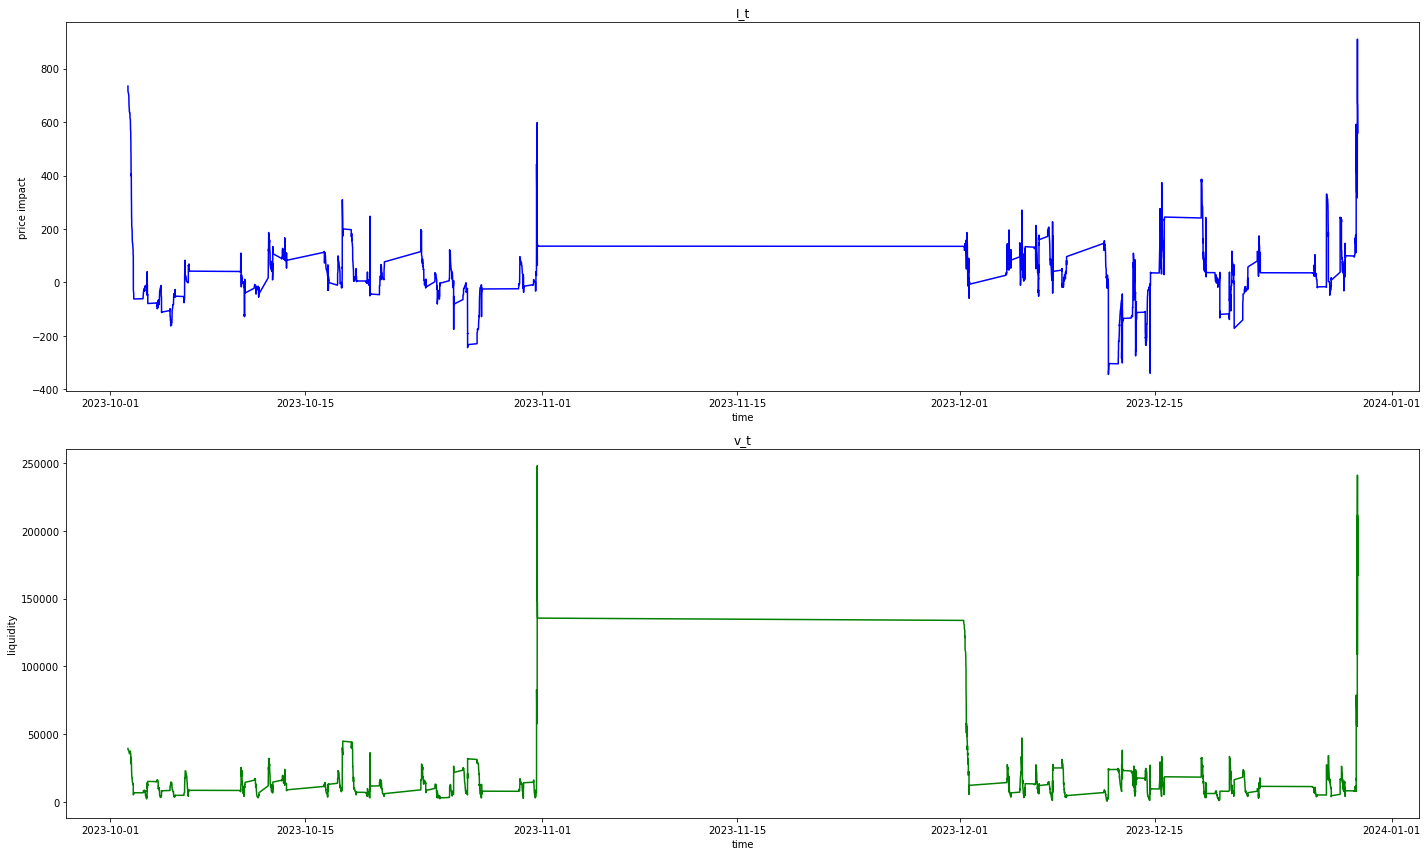

In [406]:
plt.figure(figsize=(20, 12))

# First subplot for df_it.I_t
plt.subplot(2, 1, 1)
plt.plot(df_it.I_t, color='blue')
plt.xlabel('time')
plt.ylabel('price impact')
plt.title('I_t')

# Second subplot for df_it.v_t
plt.subplot(2, 1, 2)
plt.plot(df_it.v_t, color='green')
plt.xlabel('time')
plt.ylabel('liquidity')
plt.title('v_t')

plt.tight_layout()
plt.show()


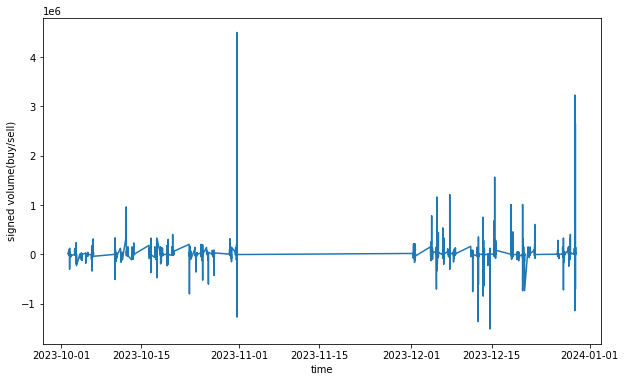

In [407]:
plt.figure(figsize=(10,6))
plt.plot(df_it.SIGNED_VOLUME)
plt.xlabel('time')
plt.ylabel('signed volume(buy/sell)')
plt.show()

# Find the optimal volume

In [409]:
import numpy as np
import math

def ow_with_optimal_volume(data, h_minutes, delta_t=1/24, target_impact=500):
    """
    Calculate impact state I_t, market activity v_t, and optimal trading volume Q_t.

    h_minutes: Time interval for return horizon (in minutes)
    delta_t: Time step for impact decay (in hours)
    target_impact: Desired target impact level (e.g., 50-60 bps)
    """
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()

    # Convert h from minutes to hours for beta calculation
    h_hours = h_minutes / 60

    # Calculate beta using half-life transformation
    beta = math.log(2) / h_hours

    # Initialize arrays for impact (I_t), liquidity (v_t), and optimal volume (Q_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))
    optimal_Q_values = np.full(len(data), np.nan)  # Placeholder for optimal trading volume

    # Initial values for I_t and v_t
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Exponential moving average with same half-life
    decay_factor = np.exp(-beta * delta_t)  # Using delta_t for decay

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma = data['Daily_Volatility'].iloc[i]
        qt = data['SIGNED_VOLUME'].iloc[i]
        adv = data['ADV'].iloc[i]

        # Update market activity using exponential moving average
        v_values[i] = decay_factor * v_values[i-1] + (1 - decay_factor) * abs(qt)

        # Calculate impact state with flow effects and impact decay
        if adv != 0 and v_values[i] != 0:
            I_values[i] = I_values[i-1] * (1 - beta * delta_t)  # Using delta_t for decay
            I_values[i] += sigma * (qt / np.sqrt(adv * v_values[i]))  # Flow effects

            # Calculate optimal Q_t based on the target impact
            Q_t = (target_impact - I_values[i] * (1 - beta * delta_t)) * np.sqrt(adv * v_values[i]) / sigma
            optimal_Q_values[i] = Q_t
        else:
            I_values[i] = I_values[i-1]  # Carry forward the previous impact state if ADV or v_t is zero

    # Assign calculated arrays back to the DataFrame
    data['I_t'] = I_values/10
    data['v_t'] = v_values
    data['Optimal_Q_t'] = abs(optimal_Q_values)

    return data

In [410]:
df_it = ow_with_optimal_volume(group1, h_minutes=120, delta_t=1/24)

In [411]:
df_it

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,...,SIGNED_VOLUME,Years to Maturity,Spread,Daily_Volatility,ADV,qt,ABS_VOLUME,I_t,v_t,Optimal_Q_t
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D38,39390.0,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,...,39390.0,1,0.005859,3.636997,380.218540,55600.5,39390.0,734.703766,39390.000000,NaN
2023-10-02 06:47:43,D28,2979.5,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,...,2979.5,3,0.027344,3.636997,380.218540,55600.5,2979.5,724.376113,38867.989894,7.017505e+06
2023-10-02 06:50:42,D38,13231.0,97.109543,91282CGV7,Note 1.5 - 3.5 Year,2026-04-15,2023-10-02,3.750,BUY,97.125000,...,13231.0,2,0.011719,3.636997,380.218540,55600.5,13231.0,715.173438,38500.437463,6.888833e+06
2023-10-02 07:46:44,D7,20200.0,99.351731,91282CHY0,Note 1.5 - 3.5 Year,2026-09-15,2023-10-02,4.625,BUY,99.367188,...,20200.0,2,0.007812,3.636997,380.218540,20200.0,20200.0,706.772698,38238.067726,6.778520e+06
2023-10-02 08:22:38,D74,2020.0,96.214676,91282CEU1,Note 1.5 - 3.5 Year,2025-06-15,2023-10-02,2.875,SELL,96.238281,...,-2020.0,1,0.019531,3.636997,380.218540,12776.5,2020.0,696.372502,37718.816483,6.625611e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:50:21,D28,80800.0,100.968918,91282CHM6,Note 1.5 - 3.5 Year,2026-07-15,2023-12-29,4.500,BUY,100.984375,...,80800.0,2,0.015625,3.605377,170.450478,10631411.5,80800.0,574.615759,173299.800260,7.783318e+06
2023-12-29 13:50:21,D38,80800.0,101.523606,91282CJC6,Note 1.5 - 3.5 Year,2026-10-15,2023-12-29,4.625,BUY,101.539062,...,80800.0,2,0.011719,3.605377,170.450478,10631411.5,80800.0,571.698597,171973.648998,7.710306e+06
2023-12-29 13:50:21,D74,141400.0,101.414231,91282CHY0,Note 1.5 - 3.5 Year,2026-09-15,2023-12-29,4.625,BUY,101.437500,...,141400.0,2,0.011719,3.605377,170.450478,10631411.5,141400.0,572.871045,171535.320666,7.717804e+06


In [412]:
# Calculate Slippage
group1['MID'] = (group1['COMP_BID'] + group1['COMP_ASK']) / 2

# Define slippage calculation function in bps
def calculate_slippage(row):
    if row['SIDE'] == 'BUY':
        return (row['PRICE'] - row['MID'])/row['MID'] * 10000 # Buy side slippage in bps; if in $: row['PRICE'] - row['MID']
    elif row['SIDE'] == 'SELL':
        return (row['MID'] - row['PRICE'])/row['MID'] * 10000 # Sell side slippage in bps; if in $: row['MID'] - row['PRICE']
    return None

def calculate_slippage_dollars(row):
    if row['SIDE'] == 'BUY':
        return (row['PRICE'] - row['MID']) # Buy side slippage in $
    elif row['SIDE'] == 'SELL':
        return (row['MID'] - row['PRICE']) # Sell side slippage in $
    return None

group1['Slippage_bps'] = group1.apply(calculate_slippage, axis=1)
group1['Slippage_dollars'] = group1.apply(calculate_slippage_dollars, axis=1)

# Total Transaction cost

In [414]:
group1['Total_Cost'] = group1['Slippage_dollars'] * group1['ACCEPTEDVOL'] * 10

total_cost = group1['Total_Cost'].sum()

print("Total Transaction Cost($):", total_cost)

Total Transaction Cost($): 2366550.446960894


# Separate the Oct and Dec

In [416]:
group1_oct_dec = group1[(group1.index.month == 10) | (group1.index.month == 12)]

# Define the time session intra day

In [418]:
def assign_time_session(timestamp):
    hour = timestamp.hour
    if 7 <= hour < 9 or (hour == 9 and timestamp.minute < 30):
        return "Pre-market"
    elif 9 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 14:
        return "Mid-day"
    elif 14 <= hour < 16:
        return "Afternoon"
    else:
        return "Post-market"

group1_oct_dec['Time_Session'] = group1_oct_dec.index.map(assign_time_session)

In [419]:
group1['MID'] = (group1['COMP_BID'] + group1['COMP_ASK']) / 2
group1['Slippage_bps'] = group1.apply(calculate_slippage, axis=1)
group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 100
# Filter data separately for October and December
group1_oct = group1[group1.index.month == 10]
group1_dec = group1[group1.index.month == 12]

group1_oct['Time_Session'] = group1_oct.index.map(assign_time_session)
group1_dec['Time_Session'] = group1_dec.index.map(assign_time_session)

group1_oct['Weighted_Slippage'] = group1_oct['Slippage_bps'] * group1_oct['ACCEPTEDVOL']

# October volume-weighted average slippage
volume_weighted_slippage_oct = group1_oct.groupby('Time_Session').apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage_bps_Oct')


group1_dec['Weighted_Slippage'] = group1_dec['Slippage_bps'] * group1_dec['ACCEPTEDVOL']

#  December volume-weighted average slippage
volume_weighted_slippage_dec = group1_dec.groupby('Time_Session').apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['SIGNED_VOLUME'].abs().sum())
).rename('Volume_Weighted_Slippage_bps_Dec')


notional_oct = group1_dec.groupby('Time_Session').apply(
    lambda x: x['Notional_Value'].sum()
).rename('Notional_Value_oct')

notional_dec = group1_dec.groupby('Time_Session').apply(
    lambda x: x['Notional_Value'].sum()
).rename('Notional_Value_dec')


print("Volume-Weighted Slippage for October:")
print(volume_weighted_slippage_oct)

print('Notional Value for October:')
print(notional_oct)

print("\nVolume-Weighted Slippage for December:")
print(volume_weighted_slippage_dec)

print('Notional Value for December:')
print(notional_dec)

Volume-Weighted Slippage for October:
Time_Session
Afternoon      0.192491
Mid-day       -0.185425
Morning       -0.079818
Post-market    0.004621
Pre-market     0.260990
Name: Volume_Weighted_Slippage_bps_Oct, dtype: float64
Notional Value for October:
Time_Session
Afternoon      1.122855e+09
Mid-day        3.383065e+09
Morning        2.565649e+09
Post-market    2.099799e+09
Pre-market     1.380651e+09
Name: Notional_Value_oct, dtype: float64

Volume-Weighted Slippage for December:
Time_Session
Afternoon      0.209703
Mid-day        0.536058
Morning        0.035030
Post-market   -0.151738
Pre-market    -0.032965
Name: Volume_Weighted_Slippage_bps_Dec, dtype: float64
Notional Value for December:
Time_Session
Afternoon      1.122855e+09
Mid-day        3.383065e+09
Morning        2.565649e+09
Post-market    2.099799e+09
Pre-market     1.380651e+09
Name: Notional_Value_dec, dtype: float64


In [420]:
df_it.columns

Index(['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE',
       'MATURITY_DATE', 'TRADEDATE', 'COUPON_RATE', 'SIDE', 'COMP_ASK',
       'COMP_BID', 'SIGN', 'SIGNED_VOLUME', 'Years to Maturity', 'Spread',
       'Daily_Volatility', 'ADV', 'qt', 'ABS_VOLUME', 'I_t', 'v_t',
       'Optimal_Q_t'],
      dtype='object')

In [421]:
import pandas as pd

# Filter the data for October and December
df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]

df_oct_dec['Time_Session'] = df_oct_dec.index.map(assign_time_session)

# Calculate Signed Volume Weighted Price Impact
df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['I_t'] #* df_oct_dec['SIGNED_VOLUME']

# Extract month and year for grouping
df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M')  # Group by month and year

# Group by Year_Month and Time_Session for monthly session-based metrics
session_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Time_Session']).agg(
    # AcceptedVol = ('ACCEPTEDVOL', 'sum'),
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Total_Signed_Volume_Weighted_Impact=('Signed_Volume_Weighted_Impact', 'mean')
)

# Calculate the signed volume weighted price impact for each session
session_metrics_monthly['Signed_Volume_Weighted_Price_Impact'] = (
    session_metrics_monthly['Total_Signed_Volume_Weighted_Impact'] #/ session_metrics_monthly['AcceptedVol']
)

# Display the results for October and December
print(session_metrics_monthly[['Signed_Volume_Weighted_Price_Impact', 'Total_Signed_Volume']])

                         Signed_Volume_Weighted_Price_Impact  \
Year_Month Time_Session                                        
2023-10    Afternoon                               31.024276   
           Mid-day                                 17.824019   
           Morning                                 24.563982   
           Post-market                             22.222260   
           Pre-market                              62.066179   
2023-12    Afternoon                                5.205161   
           Mid-day                                 85.145274   
           Morning                                 60.157179   
           Post-market                              1.722171   
           Pre-market                              64.472007   

                         Total_Signed_Volume  
Year_Month Time_Session                       
2023-10    Afternoon             10684055.73  
           Mid-day                  62109.95  
           Morning                -537408.8

# market session

## Dashboard 1

In [423]:
import pandas as pd

# Assuming `group1` and `df_it` contain the required columns and that `I_t` represents price impact.

# Step 1: Define necessary columns in `group1`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
group1['Time_Session'] = group1.index.map(assign_time_session)
group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL']
group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 100

# Calculate metrics by grouping `group1` by `Year_Month` and `Time_Session`
volume_weighted_slippage = group1.groupby(['Year_Month', 'Time_Session']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage')

notional_value = group1.groupby(['Year_Month', 'Time_Session'])['Notional_Value'].sum().rename('Notional_Value')
accepted_volume = group1.groupby(['Year_Month', 'Time_Session'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
dealer_count = group1.groupby(['Year_Month', 'Time_Session'])['DEALER'].nunique().rename('Dealer_Count')

# Combine metrics into `combined_data`
combined_data = pd.DataFrame({
    'Volume_Weighted_Slippage': volume_weighted_slippage,
    'Notional_Value': notional_value,
    'Total_Accepted_Volume': accepted_volume,
    'Dealer_Count': dealer_count
}).reset_index()

# Filter `df_it` for October and December data
df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]
df_oct_dec['Time_Session'] = df_oct_dec.index.map(assign_time_session)
df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['I_t']  # Use `I_t` directly as per your code
df_oct_dec['Upper_Limited_Volume'] = df_oct_dec['Optimal_Q_t']
df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M').astype(str)

# Group by `Year_Month` and `Time_Session` for session-based metrics
session_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Time_Session']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Price_Impact=('Signed_Volume_Weighted_Impact', 'mean'),
    Upper_Limited_Volume=('Upper_Limited_Volume', 'mean')  # Sum of optimal volumes
)

# Reset the index and confirm columns exist
session_metrics_monthly = session_metrics_monthly.reset_index()

# Ensure `Year_Month` is in string format for merging
session_metrics_monthly['Year_Month'] = session_metrics_monthly['Year_Month'].astype(str)
combined_data['Year_Month'] = combined_data['Year_Month'].astype(str)

# Merge session metrics with combined data
final_table = session_metrics_monthly.merge(
    combined_data, on=['Year_Month', 'Time_Session'], how='left'
)

# Set final index
final_table.set_index(['Year_Month', 'Time_Session'], inplace=True)
final_table['Upper_Limited_Volume'] = final_table['Upper_Limited_Volume'].round(2)
final_table['Price_Impact'] = final_table['Price_Impact'].round(2)
final_table['Volume_Weighted_Slippage'] = final_table['Volume_Weighted_Slippage'].round(4)
final_table['Notional_Value'] = final_table['Notional_Value'].round(4)
final_table['Total_Signed_Volume'] = final_table['Total_Signed_Volume'].round(2)
# Check final column names before selecting
print(final_table.columns)

# Select and display the desired columns
final_table = final_table[['Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume',
                           'Price_Impact', 'Upper_Limited_Volume', 'Volume_Weighted_Slippage', 'Dealer_Count']]

final_table

Index(['Total_Signed_Volume', 'Price_Impact', 'Upper_Limited_Volume',
       'Volume_Weighted_Slippage', 'Notional_Value', 'Total_Accepted_Volume',
       'Dealer_Count'],
      dtype='object')


Notional_Value  Total_Signed_Volume  \
Year_Month Time_Session                                        
2023-10    Afternoon       3.150259e+09          10684055.73   
           Mid-day         4.347166e+08             62109.95   
           Morning         7.943517e+08           -537408.88   
           Post-market     3.283967e+09           2595829.28   
           Pre-market      1.160907e+09           6124144.09   
2023-12    Afternoon       1.122855e+09          -2178874.01   
           Mid-day         3.383065e+09          19356836.85   
           Morning         2.565649e+09           9861615.76   
           Post-market     2.099799e+09           -665306.19   
           Pre-market      1.380651e+09           6715727.35   

                         Total_Accepted_Volume  Price_Impact  \
Year_Month Time_Session                                        
2023-10    Afternoon               31502593.87         31.02   
           Mid-day                  4347166.25         17.82   
           Morning                  7943516.68         24.56   
           Post-market             32839667.22         22.22   
           Pre-market              11609070.29         62.07   
2023-12    Afternoon               11228552.79          5.21   
           Mid-day                 33830651.95         85.15   
           Morning                 25656488.64         60.16   
           Post-market             20997991.91          1.72   
           Pre-market              13806513.15         64.47   

                         Upper_Limited_Volume  Volume_Weighted_Slippage  \
Year_Month Time_Session                                                   
2023-10    Afternoon                643504.25                    0.1925   
           Mid-day                  405016.08                   -0.1854   
           Morning                  454632.66                   -0.0798   
           Post-market              697925.50                    0.0046   
           Pre-market               830637.51                    0.2610   
2023-12    Afternoon                217776.56                    0.2097   
           Mid-day                  745644.21                    0.5361   
           Morning                  426197.57                    0.0350   
           Post-market              321880.62                   -0.1517   
           Pre-market               743356.86                   -0.0330   

                         Dealer_Count  
Year_Month Time_Session                
2023-10    Afternoon               21  
           Mid-day                 21  
           Morning                 20  
           Post-market             18  
           Pre-market              17  
2023-12    Afternoon               20  
           Mid-day                 19  
           Morning                 20  
           Post-market             21  
           Pre-market              20

## Groupby only Volatility

In [500]:
df_oct_dec['TRADEDATE'] = pd.to_datetime(df_oct_dec['TRADEDATE'])
daily_volatility = df_oct_dec.groupby('TRADEDATE')['PRICE'].std()
# Map the daily volatility back to the original DataFrame
df_oct_dec['Daily_Volatility'] = df_oct_dec['TRADEDATE'].map(daily_volatility)
max_vol = df_oct_dec['Daily_Volatility'].max()
min_vol = df_oct_dec['Daily_Volatility'].min()

In [1192]:
# Remove or handle NaN values before categorization
df_oct_dec = df_oct_dec.dropna(subset=['Daily_Volatility'])  # Remove rows with NaN volatility

# Calculate min and max after cleaning
min_vol = df_oct_dec['Daily_Volatility'].min()
max_vol = df_oct_dec['Daily_Volatility'].max()

# Then calculate terciles on clean data
q1_third = df_oct_dec['Daily_Volatility'].quantile(1/3)
q2_third = df_oct_dec['Daily_Volatility'].quantile(2/3)

# Create groups with clean data
df_oct_dec['Volatility_Group'] = pd.cut(df_oct_dec['Daily_Volatility'], 
                                       bins=[-float('inf'), q1_third, q2_third, float('inf')], 
                                       labels=['Low', 'Medium', 'High'])
volatility_counts = df_oct_dec['Volatility_Group'].value_counts().sort_index()
print("\nNumber of trades in each volatility group:")
print(volatility_counts)


Number of trades in each volatility group:
Low       4474
Medium    3722
High      4048
Name: Volatility_Group, dtype: int64


In [929]:
df_oct_dec.head()

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,...,ADV,qt,ABS_VOLUME,I_t,v_t,Optimal_Q_t,Signed_Volume_Weighted_Impact,Upper_Limited_Volume,Year_Month,Volatility_Group
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D38,39390.0,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,...,380.21854,55600.5,39390.0,734.703766,39390.000000,NaN,734.703766,NaN,2023-10,High
2023-10-02 06:47:43,D28,2979.5,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,...,380.21854,55600.5,2979.5,724.376113,38867.989894,7.017505e+06,724.376113,7.017505e+06,2023-10,High
2023-10-02 06:50:42,D38,13231.0,97.109543,91282CGV7,Note 1.5 - 3.5 Year,2026-04-15,2023-10-02,3.750,BUY,97.125000,...,380.21854,55600.5,13231.0,715.173438,38500.437463,6.888833e+06,715.173438,6.888833e+06,2023-10,High
2023-10-02 07:46:44,D7,20200.0,99.351731,91282CHY0,Note 1.5 - 3.5 Year,2026-09-15,2023-10-02,4.625,BUY,99.367188,...,380.21854,20200.0,20200.0,706.772698,38238.067726,6.778520e+06,706.772698,6.778520e+06,2023-10,High
2023-10-02 08:22:38,D74,2020.0,96.214676,91282CEU1,Note 1.5 - 3.5 Year,2025-06-15,2023-10-02,2.875,SELL,96.238281,...,380.21854,12776.5,2020.0,696.372502,37718.816483,6.625611e+06,696.372502,6.625611e+06,2023-10,High


In [931]:
group1.columns

Index(['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE',
       'MATURITY_DATE', 'TRADEDATE', 'COUPON_RATE', 'SIDE', 'COMP_ASK',
       'COMP_BID', 'SIGN', 'SIGNED_VOLUME', 'Years to Maturity', 'Spread',
       'Year_Month', 'Time_Session', 'Notional_Value'],
      dtype='object')

In [937]:
# Step 1: Define necessary columns in `group1`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
group1['Time_Session'] = group1.index.map(assign_time_session)
group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL']
group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 100
group1['Volatility_Group'] = pd.cut(group1['Daily_Volatility'], 
                                       bins=[-float('inf'), q1_third, q2_third, float('inf')], 
                                       labels=['Low', 'Medium', 'High'])

# Calculate metrics by grouping `group1` by `Year_Month` and `Time_Session`
volume_weighted_slippage = group1.groupby(['Year_Month', 'Volatility_Group']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage')

notional_value = group1.groupby(['Year_Month', 'Volatility_Group'])['Notional_Value'].sum().rename('Notional_Value')
accepted_volume = group1.groupby(['Year_Month', 'Volatility_Group'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
dealer_count = group1.groupby(['Year_Month', 'Volatility_Group'])['DEALER'].nunique().rename('Dealer_Count')

# Combine metrics into `combined_data`
combined_data = pd.DataFrame({
    'Volume_Weighted_Slippage': volume_weighted_slippage,
    'Notional_Value': notional_value,
    'Total_Accepted_Volume': accepted_volume,
    'Dealer_Count': dealer_count
}).reset_index()

KeyError: 'Slippage_bps'

In [917]:
# Filter `df_it` for October and December data
df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]

df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['I_t']  # Use `I_t` directly as per your code
df_oct_dec['Upper_Limited_Volume'] = df_oct_dec['Optimal_Q_t']
df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M').astype(str)
df_oct_dec['Volatility_Group'] = pd.cut(df_oct_dec['Daily_Volatility'], 
                                       bins=[-float('inf'), q1_third, q2_third, float('inf')], 
                                       labels=['Low', 'Medium', 'High'])

# Group by `Year_Month` and `Time_Session` for session-based metrics
session_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Volatility_Group']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Price_Impact=('Signed_Volume_Weighted_Impact', 'mean'),
    Upper_Limited_Volume=('Upper_Limited_Volume', 'sum')  # mean of optimal volumes
)

# Reset the index and confirm columns exist
session_metrics_monthly = session_metrics_monthly.reset_index()

# Ensure `Year_Month` is in string format for merging
session_metrics_monthly['Year_Month'] = session_metrics_monthly['Year_Month'].astype(str)
combined_data['Year_Month'] = combined_data['Year_Month'].astype(str)

# Merge session metrics with combined data
final_table = session_metrics_monthly.merge(
    combined_data, on=['Year_Month', 'Volatility_Group'], how='left'
)

# Set final index
final_table.set_index(['Year_Month', 'Volatility_Group'], inplace=True)
final_table['Upper_Limited_Volume'] = final_table['Upper_Limited_Volume'].round(2)
final_table['Price_Impact'] = final_table['Price_Impact'].round(2)
final_table['Volume_Weighted_Slippage'] = final_table['Volume_Weighted_Slippage'].round(4)
final_table['Notional_Value'] = final_table['Notional_Value'].round(4)
final_table['Total_Signed_Volume'] = final_table['Total_Signed_Volume'].round(2)
# Check final column names before selecting


# Select and display the desired columns
final_table = final_table[['Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume',
                           'Price_Impact', 'Upper_Limited_Volume', 'Volume_Weighted_Slippage', 'Dealer_Count']]

final_table

Notional_Value  Total_Signed_Volume  \
Year_Month Volatility_Group                                        
2023-10    Low                 2.877129e+09          -4693583.12   
           Medium              3.593628e+09           8288697.31   
           High                8.467921e+08          15333615.98   
2023-12    Low                 2.481763e+08           9795083.02   
           Medium              2.017174e+09          -7092653.29   
           High                5.125696e+09          30387570.03   

                             Total_Accepted_Volume  Price_Impact  \
Year_Month Volatility_Group                                        
2023-10    Low                         28771293.29        -28.05   
           Medium                      35936279.75         39.23   
           High                         8467920.80         54.27   
2023-12    Low                          2481762.91         53.88   
           Medium                      20171735.15        -50.05   
           High                        51256962.68        109.13   

                             Upper_Limited_Volume  Volume_Weighted_Slippage  \
Year_Month Volatility_Group                                                   
2023-10    Low                       7.835140e+08                   -0.1164   
           Medium                    4.695462e+08                   -0.0281   
           High                      1.834640e+09                   -0.2096   
2023-12    Low                       7.022267e+08                    0.0219   
           Medium                    9.597957e+08                   -0.1460   
           High                      1.509586e+09                    6.8120   

                             Dealer_Count  
Year_Month Volatility_Group                
2023-10    Low                         23  
           Medium                      21  
           High                        20  
2023-12    Low                         18  
           Medium                      24  
           High                        24

In [490]:
group2_oct_dec = group2[(group2.index.month == 10) | (group2.index.month == 12)]
group3_oct_dec = group3[(group3.index.month == 10) | (group3.index.month == 12)]
group4_oct_dec = group4[(group4.index.month == 10) | (group4.index.month == 12)]
group5_oct_dec = group5[(group5.index.month == 10) | (group5.index.month == 12)]

In [677]:
group2['MID'] = (group2['COMP_BID'] + group2['COMP_ASK']) / 2
group2['Slippage_bps'] = group2.apply(calculate_slippage, axis=1)
group2['Notional_Value'] = group2['ACCEPTEDVOL'] * 100
# Filter data separately for October and December
group2_oct = group2[group2.index.month == 10]
group2_dec = group2[group2.index.month == 12]

group2_oct['Time_Session'] = group2_oct.index.map(assign_time_session)
group2_dec['Time_Session'] = group2_dec.index.map(assign_time_session)

group2_oct['Weighted_Slippage'] = group2_oct['Slippage_bps'] * group2_oct['ACCEPTEDVOL']

# October volume-weighted average slippage
volume_weighted_slippage_oct = group2_oct.groupby('Time_Session').apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage_bps_Oct')


group2['Weighted_Slippage'] = group2['Slippage_bps'] * group2['ACCEPTEDVOL']

In [679]:
# 1. Calculate a more robust volatility measure using both standard deviation and range
# Calculate daily high-low range
daily_range = group2.groupby('TRADEDATE')['PRICE'].apply(lambda x: x.max() - x.min())
daily_std = group2.groupby('TRADEDATE')['PRICE'].std()

# Combine both metrics into a composite volatility score
group2['Range_Volatility'] = group2['TRADEDATE'].map(daily_range)
group2['Std_Volatility'] = group2['TRADEDATE'].map(daily_std)

# Normalize both measures to 0-1 scale
group2['Range_Vol_Norm'] = (group2['Range_Volatility'] - group2['Range_Volatility'].min()) / \
                          (group2['Range_Volatility'].max() - group2['Range_Volatility'].min())
group2['Std_Vol_Norm'] = (group2['Std_Volatility'] - group2['Std_Volatility'].min()) / \
                         (group2['Std_Volatility'].max() - group2['Std_Volatility'].min())

# Create composite score (equal weight to both metrics)
group2['Composite_Volatility'] = 0.5 * group2['Range_Vol_Norm'] + 0.5 * group2['Std_Vol_Norm']

# Use 30-70 percentile split instead of terciles for more emphasis on medium range
lower_bound = group2['Composite_Volatility'].quantile(0.30)
upper_bound = group2['Composite_Volatility'].quantile(0.70)

# Create the three groups
group2['Volatility_Group'] = pd.cut(group2['Composite_Volatility'],
                                   bins=[-float('inf'), lower_bound, upper_bound, float('inf')],
                                   labels=['Low', 'Medium', 'High'])

# Check distribution
print("\nVolatility Group Distribution:")
print(group2['Volatility_Group'].value_counts().sort_index())



Volatility Group Distribution:
Low       3957
Medium    4730
High      3557
Name: Volatility_Group, dtype: int64


In [683]:
#Note 0-1.5 Year 
# Step 1: Define necessary columns in `group2'
group2['Year_Month'] = group2.index.to_period('M').astype(str)
group2['Time_Session'] = group2.index.map(assign_time_session)
group2['Weighted_Slippage'] = group2['Slippage_bps'] * group2['ACCEPTEDVOL']
group2['Notional_Value'] = group2['ACCEPTEDVOL'] * 100
group2['Volatility_Group'] = pd.cut(group2['Composite_Volatility'],
                                   bins=[-float('inf'), lower_bound, upper_bound, float('inf')],
                                   labels=['Low', 'Medium', 'High'])


In [685]:
# Calculate metrics by grouping `group1` by `Year_Month` and `Time_Session`
volume_weighted_slippage = group2.groupby(['Year_Month', 'Volatility_Group']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage')

notional_value = group2.groupby(['Year_Month', 'Volatility_Group'])['Notional_Value'].sum().rename('Notional_Value')
accepted_volume = group2.groupby(['Year_Month', 'Volatility_Group'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
dealer_count = group2.groupby(['Year_Month', 'Volatility_Group'])['DEALER'].nunique().rename('Dealer_Count')

# Combine metrics into `combined_data`
combined_data = pd.DataFrame({
    'Volume_Weighted_Slippage': volume_weighted_slippage,
    'Notional_Value': notional_value,
    'Total_Accepted_Volume': accepted_volume,
    'Dealer_Count': dealer_count
}).reset_index()

In [687]:
# Filter `df_it` for October and December data
group2 = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]

group2['Signed_Volume_Weighted_Impact'] = group2['I_t']  # Use `I_t` directly as per your code
group2['Upper_Limited_Volume'] = group2['Optimal_Q_t']
group2['Year_Month'] = group2.index.to_period('M').astype(str)
group2['Volatility_Group'] = pd.cut(group2['Daily_Volatility'], 
                                       bins=[-float('inf'), q1_third, q2_third, float('inf')], 
                                       labels=['Low', 'Medium', 'High'])

# Group by `Year_Month` and `Time_Session` for session-based metrics
session_metrics_monthly = group2.groupby(['Year_Month', 'Volatility_Group']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Price_Impact=('Signed_Volume_Weighted_Impact', 'mean'),
    Upper_Limited_Volume=('Upper_Limited_Volume', 'mean')  # mean of optimal volumes
)

# Reset the index and confirm columns exist
session_metrics_monthly = session_metrics_monthly.reset_index()

# Ensure `Year_Month` is in string format for merging
session_metrics_monthly['Year_Month'] = session_metrics_monthly['Year_Month'].astype(str)
combined_data['Year_Month'] = combined_data['Year_Month'].astype(str)

# Merge session metrics with combined data
final_table = session_metrics_monthly.merge(
    combined_data, on=['Year_Month', 'Volatility_Group'], how='left'
)

# Set final index
final_table.set_index(['Year_Month', 'Volatility_Group'], inplace=True)
final_table['Upper_Limited_Volume'] = final_table['Upper_Limited_Volume'].round(2)
final_table['Price_Impact'] = final_table['Price_Impact'].round(2)
final_table['Volume_Weighted_Slippage'] = final_table['Volume_Weighted_Slippage'].round(4)
final_table['Notional_Value'] = final_table['Notional_Value'].round(4)
final_table['Total_Signed_Volume'] = final_table['Total_Signed_Volume'].round(2)
# Check final column names before selecting


# Select and display the desired columns
final_table = final_table[['Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume',
                           'Price_Impact', 'Upper_Limited_Volume', 'Volume_Weighted_Slippage', 'Dealer_Count']]

final_table

Notional_Value  Total_Signed_Volume  \
Year_Month Volatility_Group                                        
2023-10    Low                 9.744987e+08          -4693583.12   
           Medium              3.322797e+09           8288697.31   
           High                4.526906e+09          15333615.98   
2023-12    Low                 2.265757e+09           9795083.02   
           Medium              2.918424e+09          -7092653.29   
           High                5.367839e+09          30387570.03   

                             Total_Accepted_Volume  Price_Impact  \
Year_Month Volatility_Group                                        
2023-10    Low                          9744987.02        -28.05   
           Medium                      33227970.81         39.23   
           High                        45269056.48         54.27   
2023-12    Low                         22657571.39         53.88   
           Medium                      29184237.85        -50.05   
           High                        53678389.20        109.13   

                             Upper_Limited_Volume  Volume_Weighted_Slippage  \
Year_Month Volatility_Group                                                   
2023-10    Low                          500968.06                   -0.1817   
           Medium                       261877.43                   -0.0906   
           High                         927053.82                    0.2780   
2023-12    Low                          241315.01                   -0.1141   
           Medium                       497561.29                   -0.1270   
           High                         729973.68                    0.4479   

                             Dealer_Count  
Year_Month Volatility_Group                
2023-10    Low                         21  
           Medium                      20  
           High                        21  
2023-12    Low                         24  
           Medium                      21  
           High                        20

In [693]:
# Group3 Note 3.5-5.5 year
group3['MID'] = (group3['COMP_BID'] + group3['COMP_ASK']) / 2
group3['Slippage_bps'] = group3.apply(calculate_slippage, axis=1)
group3['Notional_Value'] = group3['ACCEPTEDVOL'] * 100
# Filter data separately for October and December
group3_oct = group3[group3.index.month == 10]
group3_dec = group3[group3.index.month == 12]

# October volume-weighted average slippage
volume_weighted_slippage_oct = group2_oct.groupby('Time_Session').apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage_bps_Oct')

group3['Weighted_Slippage'] = group3['Slippage_bps'] * group3['ACCEPTEDVOL']
# 1. Calculate a more robust volatility measure using both standard deviation and range
# Calculate daily high-low range
daily_range = group3.groupby('TRADEDATE')['PRICE'].apply(lambda x: x.max() - x.min())
daily_std = group3.groupby('TRADEDATE')['PRICE'].std()

# Combine both metrics into a composite volatility score
group3['Range_Volatility'] = group3['TRADEDATE'].map(daily_range)
group3['Std_Volatility'] = group3['TRADEDATE'].map(daily_std)

# Normalize both measures to 0-1 scale
group3['Range_Vol_Norm'] = (group3['Range_Volatility'] - group3['Range_Volatility'].min()) / \
                          (group3['Range_Volatility'].max() - group3['Range_Volatility'].min())
group3['Std_Vol_Norm'] = (group3['Std_Volatility'] - group3['Std_Volatility'].min()) / \
                         (group3['Std_Volatility'].max() - group3['Std_Volatility'].min())

# Create composite score (equal weight to both metrics)
group3['Composite_Volatility'] = 0.5 * group3['Range_Vol_Norm'] + 0.5 * group3['Std_Vol_Norm']

# Use 30-70 percentile split instead of terciles for more emphasis on medium range
lower_bound = group3['Composite_Volatility'].quantile(0.30)
upper_bound = group3['Composite_Volatility'].quantile(0.70)

# Create the three groups
group3['Volatility_Group'] = pd.cut(group3['Composite_Volatility'],
                                   bins=[-float('inf'), lower_bound, upper_bound, float('inf')],
                                   labels=['Low', 'Medium', 'High'])

# Check distribution
print("\nVolatility Group Distribution:")
print(group3['Volatility_Group'].value_counts().sort_index())



Volatility Group Distribution:
Low       2391
Medium    3085
High      2185
Name: Volatility_Group, dtype: int64


In [697]:
group3['Year_Month'] = group3.index.to_period('M').astype(str)
group3['Time_Session'] = group3.index.map(assign_time_session)
group3['Weighted_Slippage'] = group3['Slippage_bps'] * group3['ACCEPTEDVOL']
group3['Notional_Value'] = group3['ACCEPTEDVOL'] * 100
group3['Volatility_Group'] = pd.cut(group3['Composite_Volatility'],
                                   bins=[-float('inf'), lower_bound, upper_bound, float('inf')],
                                   labels=['Low', 'Medium', 'High'])
volume_weighted_slippage = group3.groupby(['Year_Month', 'Volatility_Group']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage')

notional_value = group3.groupby(['Year_Month', 'Volatility_Group'])['Notional_Value'].sum().rename('Notional_Value')
accepted_volume = group3.groupby(['Year_Month', 'Volatility_Group'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
dealer_count = group3.groupby(['Year_Month', 'Volatility_Group'])['DEALER'].nunique().rename('Dealer_Count')

# Combine metrics into `combined_data`
combined_data = pd.DataFrame({
    'Volume_Weighted_Slippage': volume_weighted_slippage,
    'Notional_Value': notional_value,
    'Total_Accepted_Volume': accepted_volume,
    'Dealer_Count': dealer_count
}).reset_index()

In [699]:

group3 = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]

group3['Signed_Volume_Weighted_Impact'] = group3['I_t']  # Use `I_t` directly as per your code
group3['Upper_Limited_Volume'] = group3['Optimal_Q_t']
group3['Year_Month'] = group2.index.to_period('M').astype(str)
group3['Volatility_Group'] = pd.cut(group3['Daily_Volatility'], 
                                       bins=[-float('inf'), q1_third, q2_third, float('inf')], 
                                       labels=['Low', 'Medium', 'High'])

# Group by `Year_Month` and `Time_Session` for session-based metrics
session_metrics_monthly = group3.groupby(['Year_Month', 'Volatility_Group']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Price_Impact=('Signed_Volume_Weighted_Impact', 'mean'),
    Upper_Limited_Volume=('Upper_Limited_Volume', 'mean')  # mean of optimal volumes
)

# Reset the index and confirm columns exist
session_metrics_monthly = session_metrics_monthly.reset_index()

# Ensure `Year_Month` is in string format for merging
session_metrics_monthly['Year_Month'] = session_metrics_monthly['Year_Month'].astype(str)
combined_data['Year_Month'] = combined_data['Year_Month'].astype(str)

# Merge session metrics with combined data
final_table = session_metrics_monthly.merge(
    combined_data, on=['Year_Month', 'Volatility_Group'], how='left'
)

# Set final index
final_table.set_index(['Year_Month', 'Volatility_Group'], inplace=True)
final_table['Upper_Limited_Volume'] = final_table['Upper_Limited_Volume'].round(2)
final_table['Price_Impact'] = final_table['Price_Impact'].round(2)
final_table['Volume_Weighted_Slippage'] = final_table['Volume_Weighted_Slippage'].round(4)
final_table['Notional_Value'] = final_table['Notional_Value'].round(4)
final_table['Total_Signed_Volume'] = final_table['Total_Signed_Volume'].round(2)
# Check final column names before selecting


# Select and display the desired columns
final_table = final_table[['Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume',
                           'Price_Impact', 'Upper_Limited_Volume', 'Volume_Weighted_Slippage', 'Dealer_Count']]

final_table

Notional_Value  Total_Signed_Volume  \
Year_Month Volatility_Group                                        
2023-10    Low                 2.771261e+09          -4693583.12   
           Medium              1.490908e+09           8288697.31   
           High                3.401418e+09          15333615.98   
2023-12    Low                 6.089629e+08           9795083.02   
           Medium              3.607908e+09          -7092653.29   
           High                1.740143e+09          30387570.03   

                             Total_Accepted_Volume  Price_Impact  \
Year_Month Volatility_Group                                        
2023-10    Low                         27712607.25        -28.05   
           Medium                      14909076.62         39.23   
           High                        34014177.03         54.27   
2023-12    Low                          6089629.36         53.88   
           Medium                      36079077.59        -50.05   
           High                        17401432.41        109.13   

                             Upper_Limited_Volume  Volume_Weighted_Slippage  \
Year_Month Volatility_Group                                                   
2023-10    Low                          500968.06                    0.0013   
           Medium                       261877.43                   -0.0896   
           High                         927053.82                    1.1920   
2023-12    Low                          241315.01                   -0.0917   
           Medium                       497561.29                   -0.0315   
           High                         729973.68                   -0.1246   

                             Dealer_Count  
Year_Month Volatility_Group                
2023-10    Low                         19  
           Medium                      21  
           High                        22  
2023-12    Low                         18  
           Medium                      22  
           High                        21

In [893]:
# Note 5.5 - 10 year
group4['MID'] = (group4['COMP_BID'] + group4['COMP_ASK']) / 2
group4['Slippage_bps'] = group4.apply(calculate_slippage, axis=1)
group4['Notional_Value'] = group4['ACCEPTEDVOL'] * 100

# Filter data separately for October and December
group4_oct = group4[group4.index.month == 10]
group4_dec = group4[group4.index.month == 12]

# October volume-weighted average slippage
volume_weighted_slippage_oct = group2_oct.groupby('Time_Session').apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage_bps_Oct')

group4['Weighted_Slippage'] = group4['Slippage_bps'] * group4['ACCEPTEDVOL']

# 1. Calculate a more robust volatility measure using both standard deviation and range
# Calculate daily high-low range
daily_range = group4.groupby('TRADEDATE')['PRICE'].apply(lambda x: x.max() - x.min())
daily_std = group4.groupby('TRADEDATE')['PRICE'].std()

# Combine both metrics into a composite volatility score
group4['Range_Volatility'] = group4['TRADEDATE'].map(daily_range)
group4['Std_Volatility'] = group4['TRADEDATE'].map(daily_std)

# Normalize both measures to 0-1 scale
group4['Range_Vol_Norm'] = (group4['Range_Volatility'] - group4['Range_Volatility'].min()) / \
                          (group4['Range_Volatility'].max() - group4['Range_Volatility'].min())
group4['Std_Vol_Norm'] = (group4['Std_Volatility'] - group4['Std_Volatility'].min()) / \
                         (group4['Std_Volatility'].max() - group4['Std_Volatility'].min())

# Create composite score (equal weight to both metrics)
group4['Composite_Volatility'] = 0.5 * group4['Range_Vol_Norm'] + 0.5 * group4['Std_Vol_Norm']

# Use 30-70 percentile split instead of terciles for more emphasis on medium range
lower_bound = group4['Composite_Volatility'].quantile(0.30)
upper_bound = group4['Composite_Volatility'].quantile(0.70)

# Create the three groups
group4['Volatility_Group'] = pd.cut(group4['Composite_Volatility'],
                                   bins=[-float('inf'), lower_bound, upper_bound, float('inf')],
                                   labels=['Low', 'Medium', 'High'])

# Check distribution
print("\nVolatility Group Distribution:")
print(group4['Volatility_Group'].value_counts().sort_index())


Volatility Group Distribution:
Low       2797
Medium    3600
High      2363
Name: Volatility_Group, dtype: int64


In [899]:
group4['Year_Month'] = group4.index.to_period('M').astype(str)
group4['Time_Session'] = group4.index.map(assign_time_session)
group4['Weighted_Slippage'] = group4['Slippage_bps'] * group4['ACCEPTEDVOL']
group4['Notional_Value'] = group4['ACCEPTEDVOL'] * 100
group4['Volatility_Group'] = pd.cut(group4['Composite_Volatility'],
                                   bins=[-float('inf'), lower_bound, upper_bound, float('inf')],
                                   labels=['Low', 'Medium', 'High'])

volume_weighted_slippage = group4.groupby(['Year_Month', 'Volatility_Group']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage')

notional_value = group4.groupby(['Year_Month', 'Volatility_Group'])['Notional_Value'].sum().rename('Notional_Value')
accepted_volume = group4.groupby(['Year_Month', 'Volatility_Group'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
dealer_count = group4.groupby(['Year_Month', 'Volatility_Group'])['DEALER'].nunique().rename('Dealer_Count')

# Combine metrics into `combined_data`
combined_data = pd.DataFrame({
    'Volume_Weighted_Slippage': volume_weighted_slippage,
    'Notional_Value': notional_value,
    'Total_Accepted_Volume': accepted_volume,
    'Dealer_Count': dealer_count
}).reset_index()

group4 = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]
group4['Signed_Volume_Weighted_Impact'] = group4['I_t']  # Use `I_t` directly as per your code
group4['Upper_Limited_Volume'] = group4['Optimal_Q_t']
group4['Year_Month'] = group4.index.to_period('M').astype(str)
group4['Volatility_Group'] = pd.cut(group4['Daily_Volatility'], 
                                   bins=[-float('inf'), q1_third, q2_third, float('inf')], 
                                   labels=['Low', 'Medium', 'High'])

# Group by `Year_Month` and `Time_Session` for session-based metrics
session_metrics_monthly = group4.groupby(['Year_Month', 'Volatility_Group']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Price_Impact=('Signed_Volume_Weighted_Impact', 'mean'),
    Upper_Limited_Volume=('Upper_Limited_Volume', 'mean')  # mean of optimal volumes
)

# Reset the index and confirm columns exist
session_metrics_monthly = session_metrics_monthly.reset_index()

# Ensure `Year_Month` is in string format for merging
session_metrics_monthly['Year_Month'] = session_metrics_monthly['Year_Month'].astype(str)
combined_data['Year_Month'] = combined_data['Year_Month'].astype(str)

# Merge session metrics with combined data
final_table = session_metrics_monthly.merge(
    combined_data, on=['Year_Month', 'Volatility_Group'], how='left'
)

# Set final index
final_table.set_index(['Year_Month', 'Volatility_Group'], inplace=True)

final_table['Upper_Limited_Volume'] = final_table['Upper_Limited_Volume'].round(2)
final_table['Price_Impact'] = final_table['Price_Impact'].round(2)
final_table['Volume_Weighted_Slippage'] = final_table['Volume_Weighted_Slippage'].round(4)
final_table['Notional_Value'] = final_table['Notional_Value'].round(4)
final_table['Total_Signed_Volume'] = final_table['Total_Signed_Volume'].round(2)

# Select and display the desired columns
final_table = final_table[['Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume',
                          'Price_Impact', 'Upper_Limited_Volume', 'Volume_Weighted_Slippage', 'Dealer_Count']]
final_table

KeyError: 'Slippage_bps'

In [885]:
# Note >10 year
group5['MID'] = (group5['COMP_BID'] + group5['COMP_ASK']) / 2
group5['Slippage_bps'] = group5.apply(calculate_slippage, axis=1)
group5['Notional_Value'] = group5['ACCEPTEDVOL'] * 100

# Filter data separately for October and December
group5_oct = group5[group5.index.month == 10]
group5_dec = group5[group5.index.month == 12]

group5['Weighted_Slippage'] = group5['Slippage_bps'] * group5['ACCEPTEDVOL']

# 1. Calculate a more robust volatility measure using both standard deviation and range
# Calculate daily high-low range
daily_range = group5.groupby('TRADEDATE')['PRICE'].apply(lambda x: x.max() - x.min())
daily_std = group5.groupby('TRADEDATE')['PRICE'].std()

# Combine both metrics into a composite volatility score
group5['Range_Volatility'] = group5['TRADEDATE'].map(daily_range)
group5['Std_Volatility'] = group5['TRADEDATE'].map(daily_std)

# Normalize both measures to 0-1 scale
group5['Range_Vol_Norm'] = (group5['Range_Volatility'] - group5['Range_Volatility'].min()) / \
                         (group5['Range_Volatility'].max() - group5['Range_Volatility'].min())
group5['Std_Vol_Norm'] = (group5['Std_Volatility'] - group5['Std_Volatility'].min()) / \
                        (group5['Std_Volatility'].max() - group5['Std_Volatility'].min())

# Create composite score (equal weight to both metrics)
group5['Composite_Volatility'] = 0.5 * group5['Range_Vol_Norm'] + 0.5 * group5['Std_Vol_Norm']

# Use 30-70 percentile split instead of terciles for more emphasis on medium range
lower_bound5 = group5['Composite_Volatility'].quantile(0.30)
upper_bound5 = group5['Composite_Volatility'].quantile(0.60)

# Create the three groups
group5['Volatility_Group'] = pd.cut(group5['Composite_Volatility'],
                                  bins=[-float('inf'), lower_bound5, upper_bound5, float('inf')],
                                  labels=['Low', 'Medium', 'High'])

# Check distribution
print("\nVolatility Group Distribution:")
print(group5['Volatility_Group'].value_counts().sort_index())


Volatility Group Distribution:
Low       3957
Medium    3516
High      4771
Name: Volatility_Group, dtype: int64


In [887]:
group5.columns

Index(['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE',
       'MATURITY_DATE', 'TRADEDATE', 'COUPON_RATE', 'SIDE', 'COMP_ASK',
       'COMP_BID', 'SIGN', 'SIGNED_VOLUME', 'Years to Maturity', 'Spread',
       'Daily_Volatility', 'ADV', 'qt', 'ABS_VOLUME', 'I_t', 'v_t',
       'Optimal_Q_t', 'Signed_Volume_Weighted_Impact', 'Upper_Limited_Volume',
       'Year_Month', 'Time_Session', 'MID', 'Slippage_bps', 'Slippage_dollars',
       'Weighted_Slippage', 'Notional_Value', 'Range_Volatility',
       'Std_Volatility', 'Range_Vol_Norm', 'Std_Vol_Norm',
       'Composite_Volatility', 'Volatility_Group'],
      dtype='object')

In [889]:
# Calculate Slippage
group5['MID'] = (group5['COMP_BID'] + group5['COMP_ASK']) / 2

# Define slippage calculation function in bps
def calculate_slippage(row):
    if row['SIDE'] == 'BUY':
        return (row['PRICE'] - row['MID'])/row['MID'] * 10000 # Buy side slippage in bps; if in $: row['PRICE'] - row['MID']
    elif row['SIDE'] == 'SELL':
        return (row['MID'] - row['PRICE'])/row['MID'] * 10000 # Sell side slippage in bps; if in $: row['MID'] - row['PRICE']
    return None

def calculate_slippage_dollars(row):
    if row['SIDE'] == 'BUY':
        return (row['PRICE'] - row['MID']) # Buy side slippage in $
    elif row['SIDE'] == 'SELL':
        return (row['MID'] - row['PRICE']) # Sell side slippage in $
    return None

group5['Slippage_bps'] = group5.apply(calculate_slippage, axis=1)
group5['Slippage_dollars'] = group5.apply(calculate_slippage_dollars, axis=1)

In [891]:
group5['Year_Month'] = group5.index.to_period('M').astype(str)
group5['Time_Session'] = group5.index.map(assign_time_session)
group5['Weighted_Slippage'] = group5['Slippage_bps'] * group5['ACCEPTEDVOL']
group5['Notional_Value'] = group5['ACCEPTEDVOL'] * 100
group5['Volatility_Group'] = pd.cut(group5['Composite_Volatility'],
                                   bins=[-float('inf'), lower_bound5, upper_bound5, float('inf')],
                                   labels=['Low', 'Medium', 'High'])

volume_weighted_slippage = group5.groupby(['Year_Month', 'Volatility_Group']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage')

notional_value = group5.groupby(['Year_Month', 'Volatility_Group'])['Notional_Value'].sum().rename('Notional_Value')
accepted_volume = group5.groupby(['Year_Month', 'Volatility_Group'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
dealer_count = group5.groupby(['Year_Month', 'Volatility_Group'])['DEALER'].nunique().rename('Dealer_Count')

# Combine metrics into `combined_data`
combined_data = pd.DataFrame({
    'Volume_Weighted_Slippage': volume_weighted_slippage,
    'Notional_Value': notional_value,
    'Total_Accepted_Volume': accepted_volume,
    'Dealer_Count': dealer_count
}).reset_index()

group5['Signed_Volume_Weighted_Impact'] = group5['I_t']  # Use `I_t` directly as per your code
group5['Upper_Limited_Volume'] = group5['Optimal_Q_t']
group5['Year_Month'] = group5.index.to_period('M').astype(str)
group5['Volatility_Group'] = pd.cut(group5['Composite_Volatility'],
                                   bins=[-float('inf'), lower_bound5, upper_bound5, float('inf')],
                                   labels=['Low', 'Medium', 'High'])

# Group by `Year_Month` and `Time_Session` for session-based metrics
session_metrics_monthly = group5.groupby(['Year_Month', 'Volatility_Group']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Price_Impact=('Signed_Volume_Weighted_Impact', 'mean'),
    Upper_Limited_Volume=('Upper_Limited_Volume', 'mean')  # mean of optimal volumes
)

# Reset the index and confirm columns exist
session_metrics_monthly = session_metrics_monthly.reset_index()

# Ensure `Year_Month` is in string format for merging
session_metrics_monthly['Year_Month'] = session_metrics_monthly['Year_Month'].astype(str)
combined_data['Year_Month'] = combined_data['Year_Month'].astype(str)

# Merge session metrics with combined data
final_table = session_metrics_monthly.merge(
    combined_data, on=['Year_Month', 'Volatility_Group'], how='left'
)

# Set final index
final_table.set_index(['Year_Month', 'Volatility_Group'], inplace=True)

final_table['Upper_Limited_Volume'] = final_table['Upper_Limited_Volume'].round(2)
final_table['Price_Impact'] = final_table['Price_Impact'].round(2)
final_table['Volume_Weighted_Slippage'] = final_table['Volume_Weighted_Slippage'].round(4)
final_table['Notional_Value'] = final_table['Notional_Value'].round(4)
final_table['Total_Signed_Volume'] = final_table['Total_Signed_Volume'].round(2)

# Select and display the desired columns
final_table = final_table[['Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume',
                          'Price_Impact', 'Upper_Limited_Volume', 'Volume_Weighted_Slippage', 'Dealer_Count']]
final_table

Notional_Value  Total_Signed_Volume  \
Year_Month Volatility_Group                                        
2023-10    Low                 9.744987e+08           -643614.42   
           Medium              2.706065e+09           5422151.67   
           High                5.143638e+09          14150192.92   
2023-12    Low                 2.265757e+09           7706020.23   
           Medium              2.136858e+09            529000.63   
           High                6.149404e+09          24854978.90   

                             Total_Accepted_Volume  Price_Impact  \
Year_Month Volatility_Group                                        
2023-10    Low                          9744987.02        -21.37   
           Medium                      27060648.21         58.66   
           High                        51436379.08         25.34   
2023-12    Low                         22657571.39         44.37   
           Medium                      21368583.13          8.59   
           High                        61494043.92         56.11   

                             Upper_Limited_Volume  Volume_Weighted_Slippage  \
Year_Month Volatility_Group                                                   
2023-10    Low                          391353.19                   -0.1817   
           Medium                       503066.30                   -0.1776   
           High                         802455.10                    0.2796   
2023-12    Low                          228931.47                   -0.1141   
           Medium                       500109.89                   -0.0557   
           High                         637740.33                    0.3500   

                             Dealer_Count  
Year_Month Volatility_Group                
2023-10    Low                         21  
           Medium                      19  
           High                        22  
2023-12    Low                         24  
           Medium                      19  
           High                        21

## Groupby Volume size

In [432]:
min_volume = df_oct_dec['ACCEPTEDVOL'].min()
max_volume = df_oct_dec['ACCEPTEDVOL'].max()
print(min_volume)
print(max_volume)

5.05
4499550.0


In [433]:
# Calculate the quantiles
q1 = df_oct_dec['ACCEPTEDVOL'].quantile(0.25)
q2 = df_oct_dec['ACCEPTEDVOL'].quantile(0.50)  # median
q3 = df_oct_dec['ACCEPTEDVOL'].quantile(0.75)

# Define the conditions for grouping based on quantiles
conditions = [
    (df_oct_dec['ACCEPTEDVOL'] <= q1),
    (df_oct_dec['ACCEPTEDVOL'] > q1) & (df_oct_dec['ACCEPTEDVOL'] <= q3),
    (df_oct_dec['ACCEPTEDVOL'] > q3)
]

# Define the labels for each group
labels = ['Small', 'Medium', 'Large']

# Assign groups to the 'Volume_Group' column based on quantiles
df_oct_dec['Volume_Group'] = pd.cut(df_oct_dec['ACCEPTEDVOL'], bins=[-float('inf'), q1, q3, float('inf')], labels=labels)

# Display the counts for each group to see the distribution
volume_group_counts = df_oct_dec['Volume_Group'].value_counts()
print(volume_group_counts)

Medium    5913
Small     3282
Large     3049
Name: Volume_Group, dtype: int64


In [434]:
group1['Volume_Group'] = pd.cut(group1['ACCEPTEDVOL'], bins=[-float('inf'), q1, q3, float('inf')], labels=labels)

In [435]:
# Step 1: Define necessary columns in `group1`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
group1['Time_Session'] = group1.index.map(assign_time_session)
group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL']
group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 100
group1['Volume_Group'] = pd.cut(group1['ACCEPTEDVOL'], bins=[-float('inf'), q1, q3, float('inf')], labels=labels)

# Calculate metrics by grouping `group1` by `Year_Month` and `Time_Session`
volume_weighted_slippage = group1.groupby(['Year_Month', 'Volume_Group']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage')

notional_value = group1.groupby(['Year_Month', 'Volume_Group'])['Notional_Value'].sum().rename('Notional_Value')
accepted_volume = group1.groupby(['Year_Month', 'Volume_Group'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
dealer_count = group1.groupby(['Year_Month', 'Volume_Group'])['DEALER'].nunique().rename('Dealer_Count')

# Combine metrics into `combined_data`
combined_data = pd.DataFrame({
    'Volume_Weighted_Slippage': volume_weighted_slippage,
    'Notional_Value': notional_value,
    'Total_Accepted_Volume': accepted_volume,
    'Dealer_Count': dealer_count
}).reset_index()

In [436]:
# Filter `df_it` for October and December data
df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]

df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['I_t']  # Use `I_t` directly as per your code
df_oct_dec['Upper_Limited_Volume'] = df_oct_dec['Optimal_Q_t']
df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M').astype(str)
df_oct_dec['Volume_Group'] = pd.cut(df_oct_dec['ACCEPTEDVOL'], bins=[-float('inf'), q1, q3, float('inf')], labels=labels)


# Group by `Year_Month` and `Time_Session` for session-based metrics
session_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Volume_Group']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Price_Impact=('Signed_Volume_Weighted_Impact', 'mean'),
    Upper_Limited_Volume=('Upper_Limited_Volume', 'mean')  # mean of optimal volumes
)

# Reset the index and confirm columns exist
session_metrics_monthly = session_metrics_monthly.reset_index()

# Ensure `Year_Month` is in string format for merging
session_metrics_monthly['Year_Month'] = session_metrics_monthly['Year_Month'].astype(str)
combined_data['Year_Month'] = combined_data['Year_Month'].astype(str)

# Merge session metrics with combined data
final_table = session_metrics_monthly.merge(
    combined_data, on=['Year_Month', 'Volume_Group'], how='left'
)

# Set final index
final_table.set_index(['Year_Month', 'Volume_Group'], inplace=True)
final_table['Upper_Limited_Volume'] = final_table['Upper_Limited_Volume'].round(2)
final_table['Price_Impact'] = final_table['Price_Impact'].round(2)
final_table['Volume_Weighted_Slippage'] = final_table['Volume_Weighted_Slippage'].round(4)
final_table['Notional_Value'] = final_table['Notional_Value'].round(4)
final_table['Total_Signed_Volume'] = final_table['Total_Signed_Volume'].round(2)
# Check final column names before selecting


# Select and display the desired columns
final_table = final_table[['Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume',
                           'Price_Impact', 'Upper_Limited_Volume', 'Volume_Weighted_Slippage', 'Dealer_Count']]

final_table

Notional_Value  Total_Signed_Volume  \
Year_Month Volume_Group                                        
2023-10    Small           2.698720e+06             -6100.40   
           Medium          1.759501e+08            161822.20   
           Large           8.645553e+09          18773008.37   
2023-12    Small           3.129990e+06              1969.50   
           Medium          2.522149e+08            528867.31   
           Large           1.029667e+10          32559162.95   

                         Total_Accepted_Volume  Price_Impact  \
Year_Month Volume_Group                                        
2023-10    Small                  2.698720e+04         21.65   
           Medium                 1.759501e+06          9.56   
           Large                  8.645553e+07         53.80   
2023-12    Small                  3.129990e+04         46.48   
           Medium                 2.522149e+06         29.89   
           Large                  1.029667e+08         61.26   

                         Upper_Limited_Volume  Volume_Weighted_Slippage  \
Year_Month Volume_Group                                                   
2023-10    Small                    374310.86                   -1.2849   
           Medium                   455291.64                   -1.0311   
           Large                    984346.23                    0.1117   
2023-12    Small                    369664.16                   -0.9811   
           Medium                   306874.17                   -0.8230   
           Large                    901656.54                    0.1928   

                         Dealer_Count  
Year_Month Volume_Group                
2023-10    Small                   18  
           Medium                  21  
           Large                   22  
2023-12    Small                   19  
           Medium                  21  
           Large                   24

In [440]:
final_table.columns

Index(['Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume',
       'Price_Impact', 'Upper_Limited_Volume', 'Volume_Weighted_Slippage',
       'Dealer_Count'],
      dtype='object')

In [1174]:
# Calculate Slippage
group2_oct_dec['MID'] = (group2_oct_dec['COMP_BID'] + group2_oct_dec['COMP_ASK']) / 2

# Define slippage calculation function in bps
def calculate_slippage(row):
    if row['SIDE'] == 'BUY':
        return (row['PRICE'] - row['MID'])/row['MID'] * 10000 # Buy side slippage in bps; if in $: row['PRICE'] - row['MID']
    elif row['SIDE'] == 'SELL':
        return (row['MID'] - row['PRICE'])/row['MID'] * 10000 # Sell side slippage in bps; if in $: row['MID'] - row['PRICE']
    return None

def calculate_slippage_dollars(row):
    if row['SIDE'] == 'BUY':
        return (row['PRICE'] - row['MID']) # Buy side slippage in $
    elif row['SIDE'] == 'SELL':
        return (row['MID'] - row['PRICE']) # Sell side slippage in $
    return None

group2_oct_dec['Slippage_bps'] = group2_oct_dec.apply(calculate_slippage, axis=1)
group2_oct_dec['Slippage_dollars'] = group2_oct_dec.apply(calculate_slippage_dollars, axis=1)

In [1176]:
# Calculate the quantiles
q1_group2 = group2_oct_dec['ACCEPTEDVOL'].quantile(0.25)
q2_group2 = group2_oct_dec['ACCEPTEDVOL'].quantile(0.50)  # median
q3_group2 = group2_oct_dec['ACCEPTEDVOL'].quantile(0.75)

# Define the conditions for grouping based on quantiles
conditions = [
    (group2_oct_dec['ACCEPTEDVOL'] <= q1_group2),
    (group2_oct_dec['ACCEPTEDVOL'] > q1_group2) & (group2_oct_dec['ACCEPTEDVOL'] <= q3_group2),
    (group2_oct_dec['ACCEPTEDVOL'] > q3_group2)
]

# Define the labels for each group
labels = ['Small', 'Medium', 'Large']

# Assign groups to the 'Volume_Group' column based on quantiles
group2_oct_dec['Volume_Group'] = pd.cut(group2_oct_dec['ACCEPTEDVOL'], bins=[-float('inf'), q1_group2, q3_group2, float('inf')], labels=labels)

# Display the counts for each group to see the distribution
volume_group_counts = group2_oct_dec['Volume_Group'].value_counts()
print(volume_group_counts)


Medium    5913
Small     3282
Large     3049
Name: Volume_Group, dtype: int64


In [1178]:
group2_oct_dec.columns

Index(['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE',
       'MATURITY_DATE', 'TRADEDATE', 'COUPON_RATE', 'SIDE', 'COMP_ASK',
       'COMP_BID', 'SIGN', 'SIGNED_VOLUME', 'Years to Maturity', 'Spread',
       'Daily_Volatility', 'ADV', 'qt', 'ABS_VOLUME', 'I_t', 'v_t',
       'Optimal_Q_t', 'Year_Month', 'Time_Session', 'MID', 'Slippage_bps',
       'Slippage_dollars', 'Volume_Group'],
      dtype='object')

In [1186]:
# First define group2_oct_dec from df_it
group2_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]

# Add calculated fields to group2_oct_dec
group2_oct_dec['Year_Month'] = group2_oct_dec.index.to_period('M').astype(str)
group2_oct_dec['Time_Session'] = group2_oct_dec.index.map(assign_time_session)
group2_oct_dec['Weighted_Slippage'] = group2_oct_dec['I_t'] * group2_oct_dec['ACCEPTEDVOL']  # Changed from Slippage_bps to I_t
group2_oct_dec['Notional_Value'] = group2_oct_dec['ACCEPTEDVOL'] * 100
group2_oct_dec['Volume_Group'] = pd.cut(group2_oct_dec['ACCEPTEDVOL'], bins=[-float('inf'), q1, q3, float('inf')], labels=labels)

# Calculate metrics by grouping
volume_weighted_slippage = group2_oct_dec.groupby(['Year_Month', 'Volume_Group']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage')

notional_value = group2_oct_dec.groupby(['Year_Month', 'Volume_Group'])['Notional_Value'].sum().rename('Notional_Value')
accepted_volume = group2_oct_dec.groupby(['Year_Month', 'Volume_Group'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
dealer_count = group2_oct_dec.groupby(['Year_Month', 'Volume_Group'])['DEALER'].nunique().rename('Dealer_Count')

# Combine metrics into combined_data
combined_data = pd.DataFrame({
    'Volume_Weighted_Slippage': volume_weighted_slippage,
    'Notional_Value': notional_value,
    'Total_Accepted_Volume': accepted_volume,
    'Dealer_Count': dealer_count
}).reset_index()

# Redefine group2_oct_dec with additional fields
group2_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]
group2_oct_dec['Signed_Volume_Weighted_Impact'] = group2_oct_dec['I_t']
group2_oct_dec['Upper_Limited_Volume'] = group2_oct_dec['Optimal_Q_t']
group2_oct_dec['Year_Month'] = group2_oct_dec.index.to_period('M').astype(str)

# Convert Year_Month to string type for merging
session_metrics_monthly['Year_Month'] = session_metrics_monthly['Year_Month'].astype(str)
combined_data['Year_Month'] = combined_data['Year_Month'].astype(str)

# Merge session metrics with combined data
final_table2 = session_metrics_monthly.merge(
    combined_data, on=['Year_Month', 'Volume_Group'], how='left'
)

# Set index and round values
final_table2.set_index(['Year_Month', 'Volume_Group'], inplace=True)
final_table2['Price_Impact'] = final_table2['Price_Impact'].round(2)
final_table2['Volume_Weighted_Slippage'] = final_table2['Volume_Weighted_Slippage'].round(4)
final_table2['Notional_Value'] = final_table2['Notional_Value'].round(4)
final_table2['Total_Signed_Volume'] = final_table2['Total_Signed_Volume'].round(2)

# Select final columns
final_table2 = final_table2[['Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume',
                           'Price_Impact', 'Volume_Weighted_Slippage', 'Dealer_Count']]
final_table2

Notional_Value  Total_Signed_Volume  \
Year_Month Volume_Group                                        
2023-10    Big                      NaN          17458103.51   
           Medium           175950080.0            391167.95   
           Small              2698720.0              6172.11   
2023-12    Big                      NaN           5390690.17   
           Medium           252214877.0            -39685.93   
           Small              3129990.0               300.98   

                         Total_Accepted_Volume  Price_Impact  \
Year_Month Volume_Group                                        
2023-10    Big                             NaN         -0.42   
           Medium                   1759500.80         -0.73   
           Small                      26987.20         -0.26   
2023-12    Big                             NaN         -0.33   
           Medium                   2522148.77         -0.18   
           Small                      31299.90          0.04   

                         Volume_Weighted_Slippage  Dealer_Count  
Year_Month Volume_Group                                          
2023-10    Big                                NaN           NaN  
           Medium                         15.5478          21.0  
           Small                          20.6832          18.0  
2023-12    Big                                NaN           NaN  
           Medium                         22.2806          21.0  
           Small                          45.7760          19.0

In [1089]:
# Calculate the quantiles
q1_group3 = group3_oct_dec['ACCEPTEDVOL'].quantile(0.25)
q2_group3 = group3_oct_dec['ACCEPTEDVOL'].quantile(0.50)  # median
q3_group3 = group3_oct_dec['ACCEPTEDVOL'].quantile(0.75)

# Define the conditions for grouping based on quantiles
conditions = [
    (group3_oct_dec['ACCEPTEDVOL'] <= q1_group3),
    (group3_oct_dec['ACCEPTEDVOL'] > q1_group3) & (group3_oct_dec['ACCEPTEDVOL'] <= q3_group3),
    (group3_oct_dec['ACCEPTEDVOL'] > q3_group3)
]

# Define the labels for each group
labels = ['Small', 'Medium', 'Large']

# Assign groups to the 'Volume_Group' column based on quantiles
group3_oct_dec['Volume_Group'] = pd.cut(group3_oct_dec['ACCEPTEDVOL'], bins=[-float('inf'), q1_group3, q3_group3, float('inf')], labels=labels)

# Display the counts for each group to see the distribution
volume_group_counts = group3_oct_dec['Volume_Group'].value_counts()
print(volume_group_counts)

Medium    3817
Small     1932
Large     1912
Name: Volume_Group, dtype: int64


In [1105]:
# Calculate Slippage
group3_oct_dec['MID'] = (group3_oct_dec['COMP_BID'] + group3_oct_dec['COMP_ASK']) / 2

# Define slippage calculation function in bps
def calculate_slippage(row):
    if row['SIDE'] == 'BUY':
        return (row['PRICE'] - row['MID'])/row['MID'] * 10000 # Buy side slippage in bps; if in $: row['PRICE'] - row['MID']
    elif row['SIDE'] == 'SELL':
        return (row['MID'] - row['PRICE'])/row['MID'] * 10000 # Sell side slippage in bps; if in $: row['MID'] - row['PRICE']
    return None

def calculate_slippage_dollars(row):
    if row['SIDE'] == 'BUY':
        return (row['PRICE'] - row['MID']) # Buy side slippage in $
    elif row['SIDE'] == 'SELL':
        return (row['MID'] - row['PRICE']) # Sell side slippage in $
    return None

group3_oct_dec['Slippage_bps'] = group3_oct_dec.apply(calculate_slippage, axis=1)
group3_oct_dec['Slippage_dollars'] = group3_oct_dec.apply(calculate_slippage_dollars, axis=1)
group3_oct_dec['Year_Month'] = group3_oct_dec.index.to_period('M').astype(str)
group3_oct_dec['Time_Session'] = group3_oct_dec.index.map(assign_time_session)
group3_oct_dec['Weighted_Slippage'] = group3_oct_dec['Slippage_bps'] * group3_oct_dec['ACCEPTEDVOL']
group3_oct_dec['Notional_Value'] = group3_oct_dec['ACCEPTEDVOL'] * 100
group3_oct_dec['Volume_Group'] = pd.cut(group3_oct_dec['ACCEPTEDVOL'], bins=[-float('inf'), q1_group3, q3_group3, float('inf')], labels=labels)

# Calculate metrics by grouping `group1` by `Year_Month` and `Time_Session`
volume_weighted_slippage3 = group3_oct_dec.groupby(['Year_Month', 'Volume_Group']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage')

notional_value3 = group3_oct_dec.groupby(['Year_Month', 'Volume_Group'])['Notional_Value'].sum().rename('Notional_Value')
accepted_volume3 = group3_oct_dec.groupby(['Year_Month', 'Volume_Group'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
dealer_count3 = group3_oct_dec.groupby(['Year_Month', 'Volume_Group'])['DEALER'].nunique().rename('Dealer_Count')


In [1111]:
combined_data3 = pd.DataFrame({
    'Volume_Weighted_Slippage': volume_weighted_slippage3,
    'Notional_Value': notional_value3,
    'Total_Accepted_Volume': accepted_volume3,
    'Dealer_Count': dealer_count3
}).reset_index()

group3_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]
group3_oct_dec['Signed_Volume_Weighted_Impact'] = group3_oct_dec['I_t']  # Use `I_t` directly as per your code
group3_oct_dec['Upper_Limited_Volume'] = group3_oct_dec['Optimal_Q_t']
group3_oct_dec['Year_Month'] = group3_oct_dec.index.to_period('M').astype(str)
group3_oct_dec['Volume_Group'] = pd.cut(group3_oct_dec['ACCEPTEDVOL'], bins=[-float('inf'), q1_group3, q3_group3, float('inf')], labels=labels)

session_metrics_monthly3 = group3_oct_dec.groupby(['Year_Month', 'Volume_Group']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Price_Impact=('Signed_Volume_Weighted_Impact', 'mean'),
    Upper_Limited_Volume=('Upper_Limited_Volume', 'mean')  # mean of optimal volumes
)

# Ensure `Year_Month` is in string format for merging
combined_data3['Year_Month'] = combined_data3['Year_Month'].astype(str)

# Merge session metrics with combined data
final_table3 = session_metrics_monthly3.merge(
    combined_data3, on=['Year_Month', 'Volume_Group'], how='left'
)

# Set final index
final_table3.set_index(['Year_Month', 'Volume_Group'], inplace=True)
final_table3['Upper_Limited_Volume'] = final_table3['Upper_Limited_Volume'].round(2)
final_table3['Price_Impact'] = final_table3['Price_Impact'].round(2)
final_table3['Volume_Weighted_Slippage'] = final_table3['Volume_Weighted_Slippage'].round(4)
final_table3['Notional_Value'] = final_table3['Notional_Value'].round(4)
final_table3['Total_Signed_Volume'] = final_table3['Total_Signed_Volume'].round(2)
# Check final column names before selecting


# Select and display the desired columns
final_table3 = final_table[['Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume',
                           'Price_Impact', 'Upper_Limited_Volume', 'Volume_Weighted_Slippage', 'Dealer_Count']]

final_table3

Notional_Value  Total_Signed_Volume  \
Year_Month Volume_Group                                        
2023-10    Big                      NaN          10525210.00   
           Medium           170694040.0           8407196.57   
           Small              2698720.0             -3676.40   
2023-12    Big                      NaN           3229929.50   
           Medium           240759457.0          29849636.96   
           Small              3129990.0             10433.30   

                         Total_Accepted_Volume  Price_Impact  \
Year_Month Volume_Group                                        
2023-10    Big                             NaN        507.02   
           Medium                   1706940.40         27.06   
           Small                      26987.20         20.54   
2023-12    Big                             NaN        592.14   
           Medium                   2407594.57         39.98   
           Small                      31299.90         44.00   

                         Upper_Limited_Volume  Volume_Weighted_Slippage  \
Year_Month Volume_Group                                                   
2023-10    Big                     9458039.68                       NaN   
           Medium                   676745.01                   -1.0387   
           Small                    376496.26                   -1.2849   
2023-12    Big                     4815879.53                       NaN   
           Medium                   512008.05                   -0.8233   
           Small                    351024.41                   -0.9811   

                         Dealer_Count  
Year_Month Volume_Group                
2023-10    Big                    NaN  
           Medium                21.0  
           Small                 18.0  
2023-12    Big                    NaN  
           Medium                21.0  
           Small                 19.0

In [1188]:
print("Available columns in group2_oct_dec:")
print(group2_oct_dec.columns.tolist())

# Calculate basic metrics
group2_oct_dec['MID'] = (group2_oct_dec['COMP_BID'] + group2_oct_dec['COMP_ASK']) / 2
group2_oct_dec['Slippage_bps'] = group2_oct_dec.apply(calculate_slippage, axis=1)
group2_oct_dec['Notional_Value'] = group2_oct_dec['ACCEPTEDVOL'] * 100
group2_oct_dec['Year_Month'] = group2_oct_dec.index.to_period('M').astype(str)
group2_oct_dec['Weighted_Slippage'] = group2_oct_dec['Slippage_bps'] * group2_oct_dec['ACCEPTEDVOL']

# Create volume groups using Total_Accepted_Volume
def categorize_volume(df):
    volume_data = df[df['ACCEPTEDVOL'] > 0]['ACCEPTEDVOL']
    
    # Calculate volume thresholds
    lower_threshold = volume_data.quantile(0.33)
    upper_threshold = volume_data.quantile(0.67)
    
    conditions = [
        (df['ACCEPTEDVOL'] > 0) & (df['ACCEPTEDVOL'] <= lower_threshold),
        (df['ACCEPTEDVOL'] > lower_threshold) & (df['ACCEPTEDVOL'] <= upper_threshold),
        (df['ACCEPTEDVOL'] > upper_threshold)
    ]
    choices = ['Small', 'Medium', 'Big']
    
    return pd.Series(np.select(conditions, choices, default='Medium'), index=df.index)

# Apply volume categorization
group2_oct_dec['Volume_Group'] = categorize_volume(group2_oct_dec)

# Calculate metrics grouped by Year_Month and Volume_Group
volume_weighted_slippage = group2_oct_dec.groupby(['Year_Month', 'Volume_Group']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage')

notional_value = group2_oct_dec.groupby(['Year_Month', 'Volume_Group'])['Notional_Value'].sum().rename('Notional_Value')
accepted_volume = group2_oct_dec.groupby(['Year_Month', 'Volume_Group'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
dealer_count = group2_oct_dec.groupby(['Year_Month', 'Volume_Group'])['DEALER'].nunique().rename('Dealer_Count')
trade_count = group2_oct_dec.groupby(['Year_Month', 'Volume_Group']).size().rename('number_of_trade')

# Process session metrics with available columns only
session_metrics_monthly = group2_oct_dec.groupby(['Year_Month', 'Volume_Group']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum')
)

# Combine all metrics into one DataFrame
combined_data = pd.DataFrame({
    'Volume_Weighted_Slippage': volume_weighted_slippage,
    'Notional_Value': notional_value,
    'Total_Accepted_Volume': accepted_volume,
    'Dealer_Count': dealer_count,
    'number_of_trade': trade_count
}).reset_index()

# Reset index and prepare for merge
session_metrics_monthly = session_metrics_monthly.reset_index()
session_metrics_monthly['Year_Month'] = session_metrics_monthly['Year_Month'].astype(str)
combined_data['Year_Month'] = combined_data['Year_Month'].astype(str)

# Merge and create final table
final_table = session_metrics_monthly.merge(
    combined_data, on=['Year_Month', 'Volume_Group'], how='left'
)

# Set index and round values
final_table.set_index(['Year_Month', 'Volume_Group'], inplace=True)
final_table['Volume_Weighted_Slippage'] = final_table['Volume_Weighted_Slippage'].round(4)
final_table['Notional_Value'] = final_table['Notional_Value'].round(4)
final_table['Total_Signed_Volume'] = final_table['Total_Signed_Volume'].round(2)

# Select and order final columns
final_table = final_table[['Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume',
                          'Volume_Weighted_Slippage', 'Dealer_Count', 'number_of_trade']]

print("\nFinal table:")
print(final_table)

# Count the number of trades in each volume group
volume_group_counts = group2_oct_dec['Volume_Group'].value_counts().sort_index()
print("\nNumber of trades in each volume group:")
print(volume_group_counts)

# Calculate percentage distribution
volume_group_percentage = group2_oct_dec['Volume_Group'].value_counts(normalize=True).sort_index() * 100
print("\nPercentage of trades in each volume group:")
print(volume_group_percentage.round(2), "%")

# Show monthly distribution
monthly_counts = group2_oct_dec.groupby(['Year_Month', 'Volume_Group'])['Volume_Group'].count().unstack(fill_value=0)
print("\nNumber of trades by month and volume group:")
print(monthly_counts)

Available columns in group2_oct_dec:
['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE', 'MATURITY_DATE', 'TRADEDATE', 'COUPON_RATE', 'SIDE', 'COMP_ASK', 'COMP_BID', 'SIGN', 'SIGNED_VOLUME', 'Years to Maturity', 'Spread', 'Daily_Volatility', 'ADV', 'qt', 'ABS_VOLUME', 'I_t', 'v_t', 'Optimal_Q_t', 'Signed_Volume_Weighted_Impact', 'Upper_Limited_Volume', 'Year_Month']

Final table:
                         Notional_Value  Total_Signed_Volume  \
Year_Month Volume_Group                                        
2023-10    Big             8.736156e+09          18735916.12   
           Medium          8.312250e+07            196490.45   
           Small           4.922740e+06             -3676.40   
2023-12    Big             1.042454e+10          32690549.81   
           Medium          1.212627e+08            389016.65   
           Small           6.216550e+06             10433.30   

                         Total_Accepted_Volume  Volume_Weighted_Slippage  \
Year_Month Vo

In [1123]:
# First, let's see what columns are available
print("Available columns in group3_oct_dec:")
print(group3_oct_dec.columns.tolist())

# Group 3 Note 3.5-5.5 year processing with volume grouping
# Calculate basic metrics
group3_oct_dec['MID'] = (group3_oct_dec['COMP_BID'] + group3_oct_dec['COMP_ASK']) / 2
group3_oct_dec['Slippage_bps'] = group3_oct_dec.apply(calculate_slippage, axis=1)
group3_oct_dec['Notional_Value'] = group3_oct_dec['ACCEPTEDVOL'] * 100
group3_oct_dec['Year_Month'] = group3_oct_dec.index.to_period('M').astype(str)
group3_oct_dec['Weighted_Slippage'] = group3_oct_dec['Slippage_bps'] * group3_oct_dec['ACCEPTEDVOL']
group3_oct_dec['Price_Impact'] = ((group3_oct_dec['PRICE'] - group3_oct_dec['MID']) / group3_oct_dec['MID']) * 10000

# Create volume groups using Total_Accepted_Volume
def categorize_volume(df):
    volume_data = df[df['ACCEPTEDVOL'] > 0]['ACCEPTEDVOL']
    
    # Calculate volume thresholds
    lower_threshold = volume_data.quantile(0.33)
    upper_threshold = volume_data.quantile(0.67)
    
    conditions = [
        (df['ACCEPTEDVOL'] > 0) & (df['ACCEPTEDVOL'] <= lower_threshold),
        (df['ACCEPTEDVOL'] > lower_threshold) & (df['ACCEPTEDVOL'] <= upper_threshold),
        (df['ACCEPTEDVOL'] > upper_threshold)
    ]
    choices = ['Small', 'Medium', 'Big']
    
    return pd.Series(np.select(conditions, choices, default='Medium'), index=df.index)

# Apply volume categorization
group3_oct_dec['Volume_Group'] = categorize_volume(group3_oct_dec)

# Calculate metrics grouped by Year_Month and Volume_Group
volume_weighted_slippage = group3_oct_dec.groupby(['Year_Month', 'Volume_Group']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage')

notional_value = group3_oct_dec.groupby(['Year_Month', 'Volume_Group'])['Notional_Value'].sum().rename('Notional_Value')
accepted_volume = group3_oct_dec.groupby(['Year_Month', 'Volume_Group'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
dealer_count = group3_oct_dec.groupby(['Year_Month', 'Volume_Group'])['DEALER'].nunique().rename('Dealer_Count')

# Process session metrics with only available columns
session_metrics_monthly = group3_oct_dec.groupby(['Year_Month', 'Volume_Group']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Price_Impact=('Signed_Volume_Weighted_Impact', 'mean'),
    Upper_Limited_Volume=('Upper_Limited_Volume', 'mean')  # mean of optimal volumes
    
)

# Combine all metrics into one DataFrame
combined_data = pd.DataFrame({
    'Volume_Weighted_Slippage': volume_weighted_slippage,
    'Notional_Value': notional_value,
    'Total_Accepted_Volume': accepted_volume,
    'Dealer_Count': dealer_count
}).reset_index()

# Reset index and prepare for merge
session_metrics_monthly = session_metrics_monthly.reset_index()
session_metrics_monthly['Year_Month'] = session_metrics_monthly['Year_Month'].astype(str)
combined_data['Year_Month'] = combined_data['Year_Month'].astype(str)

# Merge and create final table
final_table = session_metrics_monthly.merge(
    combined_data, on=['Year_Month', 'Volume_Group'], how='left'
)

# Set index and round values
final_table.set_index(['Year_Month', 'Volume_Group'], inplace=True)
final_table['Volume_Weighted_Slippage'] = final_table['Volume_Weighted_Slippage'].round(4)
final_table['Notional_Value'] = final_table['Notional_Value'].round(4)
final_table['Total_Signed_Volume'] = final_table['Total_Signed_Volume'].round(2)

print("\nFinal table:")
print(final_table)

Available columns in group3_oct_dec:
['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE', 'MATURITY_DATE', 'TRADEDATE', 'COUPON_RATE', 'SIDE', 'COMP_ASK', 'COMP_BID', 'SIGN', 'SIGNED_VOLUME', 'Years to Maturity', 'Spread', 'Daily_Volatility', 'ADV', 'qt', 'ABS_VOLUME', 'I_t', 'v_t', 'Optimal_Q_t', 'Signed_Volume_Weighted_Impact', 'Upper_Limited_Volume', 'Year_Month', 'Volume_Group', 'MID', 'Slippage_bps', 'Notional_Value', 'Weighted_Slippage', 'Price_Impact']

Final table:
                         Total_Signed_Volume  Price_Impact  \
Year_Month Volume_Group                                      
2023-10    Big                   18735916.12     45.245362   
           Medium                  196490.45      7.229828   
           Small                    -3676.40     20.542051   
2023-12    Big                   32690549.81     51.414934   
           Medium                  389016.65     30.187658   
           Small                    10433.30     44.004786   

           

In [1129]:
volume_group_counts = group3_oct_dec['Volume_Group'].value_counts().sort_index()
print("\nNumber of trades in each volume group:")
print(volume_group_counts)


Number of trades in each volume group:
Big       4021
Medium    4099
Small     4124
Name: Volume_Group, dtype: int64


In [1150]:
print("Available columns in group4_oct_dec:")
print(group4_oct_dec.columns.tolist())

# Calculate basic metrics
group4_oct_dec['MID'] = (group4_oct_dec['COMP_BID'] + group4_oct_dec['COMP_ASK']) / 2
group4_oct_dec['Slippage_bps'] = group4_oct_dec.apply(calculate_slippage, axis=1)
group4_oct_dec['Notional_Value'] = group4_oct_dec['ACCEPTEDVOL'] * 100
group4_oct_dec['Year_Month'] = group4_oct_dec.index.to_period('M').astype(str)
group4_oct_dec['Weighted_Slippage'] = group4_oct_dec['Slippage_bps'] * group4_oct_dec['ACCEPTEDVOL']

# Create volume groups using Total_Accepted_Volume
def categorize_volume(df):
    volume_data = df[df['ACCEPTEDVOL'] > 0]['ACCEPTEDVOL']
    
    # Calculate volume thresholds
    lower_threshold = volume_data.quantile(0.33)
    upper_threshold = volume_data.quantile(0.67)
    
    conditions = [
        (df['ACCEPTEDVOL'] > 0) & (df['ACCEPTEDVOL'] <= lower_threshold),
        (df['ACCEPTEDVOL'] > lower_threshold) & (df['ACCEPTEDVOL'] <= upper_threshold),
        (df['ACCEPTEDVOL'] > upper_threshold)
    ]
    choices = ['Small', 'Medium', 'Big']
    
    return pd.Series(np.select(conditions, choices, default='Medium'), index=df.index)

# Apply volume categorization
group4_oct_dec['Volume_Group'] = categorize_volume(group4_oct_dec)

# Calculate metrics grouped by Year_Month and Volume_Group
volume_weighted_slippage = group4_oct_dec.groupby(['Year_Month', 'Volume_Group']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage')

notional_value = group4_oct_dec.groupby(['Year_Month', 'Volume_Group'])['Notional_Value'].sum().rename('Notional_Value')
accepted_volume = group4_oct_dec.groupby(['Year_Month', 'Volume_Group'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
dealer_count = group4_oct_dec.groupby(['Year_Month', 'Volume_Group'])['DEALER'].nunique().rename('Dealer_Count')
trade_count = group4_oct_dec.groupby(['Year_Month', 'Volume_Group']).size().rename('number_of_trade')

# Process session metrics with available columns only
session_metrics_monthly = group4_oct_dec.groupby(['Year_Month', 'Volume_Group']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum')
)

# Combine all metrics into one DataFrame
combined_data = pd.DataFrame({
    'Volume_Weighted_Slippage': volume_weighted_slippage,
    'Notional_Value': notional_value,
    'Total_Accepted_Volume': accepted_volume,
    'Dealer_Count': dealer_count,
    'number_of_trade': trade_count
}).reset_index()

# Reset index and prepare for merge
session_metrics_monthly = session_metrics_monthly.reset_index()
session_metrics_monthly['Year_Month'] = session_metrics_monthly['Year_Month'].astype(str)
combined_data['Year_Month'] = combined_data['Year_Month'].astype(str)

# Merge and create final table
final_table = session_metrics_monthly.merge(
    combined_data, on=['Year_Month', 'Volume_Group'], how='left'
)

# Set index and round values
final_table.set_index(['Year_Month', 'Volume_Group'], inplace=True)
final_table['Volume_Weighted_Slippage'] = final_table['Volume_Weighted_Slippage'].round(4)
final_table['Notional_Value'] = final_table['Notional_Value'].round(4)
final_table['Total_Signed_Volume'] = final_table['Total_Signed_Volume'].round(2)

# Select and order final columns
final_table = final_table[['Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume',
                          'Volume_Weighted_Slippage', 'Dealer_Count', 'number_of_trade']]

print("\nFinal table:")
print(final_table)

# Count the number of trades in each volume group
volume_group_counts = group4_oct_dec['Volume_Group'].value_counts().sort_index()
print("\nNumber of trades in each volume group:")
print(volume_group_counts)

# Calculate percentage distribution
volume_group_percentage = group4_oct_dec['Volume_Group'].value_counts(normalize=True).sort_index() * 100
print("\nPercentage of trades in each volume group:")
print(volume_group_percentage.round(2), "%")

# Show monthly distribution
monthly_counts = group4_oct_dec.groupby(['Year_Month', 'Volume_Group'])['Volume_Group'].count().unstack(fill_value=0)
print("\nNumber of trades by month and volume group:")
print(monthly_counts)

Available columns in group4_oct_dec:
['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE', 'MATURITY_DATE', 'TRADEDATE', 'COUPON_RATE', 'SIDE', 'COMP_ASK', 'COMP_BID', 'SIGN', 'SIGNED_VOLUME', 'Years to Maturity', 'Spread', 'MID', 'Slippage_bps', 'Notional_Value', 'Year_Month', 'Weighted_Slippage', 'Volume_Group', 'Price_Impact']

Final table:
                         Notional_Value  Total_Signed_Volume  \
Year_Month Volume_Group                                        
2023-10    Big             7.226421e+09            596402.98   
           Medium          8.791525e+07            191124.32   
           Small           3.212810e+06              2292.70   
2023-12    Big             7.313520e+09          20322131.22   
           Medium          7.450447e+07            127524.62   
           Small           3.021314e+06              5197.46   

                         Total_Accepted_Volume  Volume_Weighted_Slippage  \
Year_Month Volume_Group                             

In [1162]:
group5_oct_dec.columns

Index(['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE',
       'MATURITY_DATE', 'TRADEDATE', 'COUPON_RATE', 'SIDE', 'COMP_ASK',
       'COMP_BID', 'SIGN', 'SIGNED_VOLUME', 'Years to Maturity', 'Spread',
       'MID', 'Slippage_bps', 'Notional_Value', 'Year_Month',
       'Weighted_Slippage', 'Volume_Group', 'Price_Impact'],
      dtype='object')

In [1164]:
print("Available columns in group5_oct_dec:")
print(group5_oct_dec.columns.tolist())

# Calculate basic metrics
group5_oct_dec['MID'] = (group5_oct_dec['COMP_BID'] + group5_oct_dec['COMP_ASK']) / 2
group5_oct_dec['Slippage_bps'] = group5_oct_dec.apply(calculate_slippage, axis=1)
group5_oct_dec['Notional_Value'] = group5_oct_dec['ACCEPTEDVOL'] * 100
group5_oct_dec['Year_Month'] = group5_oct_dec.index.to_period('M').astype(str)
group5_oct_dec['Weighted_Slippage'] = group5_oct_dec['Slippage_bps'] * group5_oct_dec['ACCEPTEDVOL']

# Calculate Price Impact
group5_oct_dec['Price_Impact'] = ((group5_oct_dec['PRICE'] - group5_oct_dec['MID']) / group5_oct_dec['MID']) * 10000

# Create volume groups using Total_Accepted_Volume
def categorize_volume(df):
   volume_data = df[df['ACCEPTEDVOL'] > 0]['ACCEPTEDVOL']
   
   # Calculate volume thresholds
   lower_threshold = volume_data.quantile(0.33)
   upper_threshold = volume_data.quantile(0.67)
   
   conditions = [
       (df['ACCEPTEDVOL'] > 0) & (df['ACCEPTEDVOL'] <= lower_threshold),
       (df['ACCEPTEDVOL'] > lower_threshold) & (df['ACCEPTEDVOL'] <= upper_threshold),
       (df['ACCEPTEDVOL'] > upper_threshold)
   ]
   choices = ['Small', 'Medium', 'Big']
   
   return pd.Series(np.select(conditions, choices, default='Medium'), index=df.index)

# Apply volume categorization
group5_oct_dec['Volume_Group'] = categorize_volume(group5_oct_dec)

# Calculate metrics grouped by Year_Month and Volume_Group
volume_weighted_slippage = group5_oct_dec.groupby(['Year_Month', 'Volume_Group']).apply(
   lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage')

notional_value = group5_oct_dec.groupby(['Year_Month', 'Volume_Group'])['Notional_Value'].sum().rename('Notional_Value')
accepted_volume = group5_oct_dec.groupby(['Year_Month', 'Volume_Group'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
dealer_count = group5_oct_dec.groupby(['Year_Month', 'Volume_Group'])['DEALER'].nunique().rename('Dealer_Count')
trade_count = group5_oct_dec.groupby(['Year_Month', 'Volume_Group']).size().rename('number_of_trade')

# Process session metrics including Price Impact
session_metrics_monthly = group5_oct_dec.groupby(['Year_Month', 'Volume_Group']).agg(
   Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
   Price_Impact=('Price_Impact', 'mean')  # Added Price Impact
)

# Combine all metrics into one DataFrame
combined_data = pd.DataFrame({
   'Volume_Weighted_Slippage': volume_weighted_slippage,
   'Notional_Value': notional_value,
   'Total_Accepted_Volume': accepted_volume,
   'Dealer_Count': dealer_count,
   'number_of_trade': trade_count
}).reset_index()

# Reset index and prepare for merge
session_metrics_monthly = session_metrics_monthly.reset_index()
session_metrics_monthly['Year_Month'] = session_metrics_monthly['Year_Month'].astype(str)
combined_data['Year_Month'] = combined_data['Year_Month'].astype(str)

# Merge and create final table
final_table = session_metrics_monthly.merge(
   combined_data, on=['Year_Month', 'Volume_Group'], how='left'
)

# Set index and round values
final_table.set_index(['Year_Month', 'Volume_Group'], inplace=True)
final_table['Price_Impact'] = final_table['Price_Impact'].round(2)  # Round Price Impact
final_table['Volume_Weighted_Slippage'] = final_table['Volume_Weighted_Slippage'].round(4)
final_table['Notional_Value'] = final_table['Notional_Value'].round(4)
final_table['Total_Signed_Volume'] = final_table['Total_Signed_Volume'].round(2)

# Select and order final columns including Price Impact
final_table = final_table[['Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume',
                         'Price_Impact', 'Volume_Weighted_Slippage', 
                         'Dealer_Count', 'number_of_trade']]

print("\nFinal table:")
print(final_table)

# Count the number of trades in each volume group
volume_group_counts = group5_oct_dec['Volume_Group'].value_counts().sort_index()
print("\nNumber of trades in each volume group:")
print(volume_group_counts)

# Calculate percentage distribution
volume_group_percentage = group5_oct_dec['Volume_Group'].value_counts(normalize=True).sort_index() * 100
print("\nPercentage of trades in each volume group:")
print(volume_group_percentage.round(2), "%")

# Show monthly distribution
monthly_counts = group5_oct_dec.groupby(['Year_Month', 'Volume_Group'])['Volume_Group'].count().unstack(fill_value=0)
print("\nNumber of trades by month and volume group:")
print(monthly_counts)

Available columns in group5_oct_dec:
['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE', 'MATURITY_DATE', 'TRADEDATE', 'COUPON_RATE', 'SIDE', 'COMP_ASK', 'COMP_BID', 'SIGN', 'SIGNED_VOLUME', 'Years to Maturity', 'Spread', 'MID', 'Slippage_bps', 'Notional_Value', 'Year_Month', 'Weighted_Slippage', 'Volume_Group', 'Price_Impact']

Final table:
                         Notional_Value  Total_Signed_Volume  \
Year_Month Volume_Group                                        
2023-10    Big             6.892941e+09          17458103.51   
           Medium          1.230658e+08            391167.95   
           Small           3.857089e+06              6172.11   
2023-12    Big             5.842214e+09           5390690.17   
           Medium          8.527501e+07            -39685.93   
           Small           4.184632e+06               300.98   

                         Total_Accepted_Volume  Price_Impact  \
Year_Month Volume_Group                                        


# first 3 weeks and last week

## Dashboard 2

In [442]:
import pandas as pd

# Step 1: Define Year_Month, Week_Group, and Time_Session in `group1`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
group1['Time_Session'] = group1.index.map(assign_time_session)
group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL']
group1['ACCEPTED_Volume'] = group1['ACCEPTEDVOL']

# Step 2: Calculate metrics for each Year_Month and Week_Group
# Calculate Volume Weighted Slippage
volume_weighted_slippage = group1.groupby(['Year_Month', 'Week_Group']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage')

# Calculate Notional Value
notional_value = group1.groupby(['Year_Month', 'Week_Group'])['Notional_Value'].sum().rename('Notional_Value')

# Calculate Dealer Count (unique dealers per Year_Month and Week_Group)
dealer_count = group1.groupby(['Year_Month', 'Week_Group'])['DEALER'].nunique().rename('Dealer_Count')

total_volume = group1.groupby(['Year_Month', 'Week_Group'])['ACCEPTED_Volume'].sum().rename('Total_Accepted_Volume')


# Combine metrics into a single DataFrame
combined_data = pd.DataFrame({
    'Volume_Weighted_Slippage': volume_weighted_slippage,
    'Notional_Value': notional_value,
    'Dealer_Count': dealer_count,
    'Total_Accepted_Volume': total_volume

}).reset_index()

# Step 3: Process `df_it` for Signed Volume Weighted Price Impact with week grouping
df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]
df_oct_dec['Time_Session'] = df_oct_dec.index.map(assign_time_session)
df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['I_t']  # Use `I_t` directly
df_oct_dec['Upper_Limited_Volume'] = df_oct_dec['Optimal_Q_t']
df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M').astype(str)
df_oct_dec['Week_Group'] = df_oct_dec.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')

# Group by Year_Month and Week_Group for session-based metrics
session_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Week_Group']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Total_Signed_Volume_Weighted_Impact=('Signed_Volume_Weighted_Impact', 'mean'),
    Upper_Limited_Volume = ('Upper_Limited_Volume', 'mean')
)

# Calculate Average Price Impact
session_metrics_monthly['Average_Price_Impact'] = session_metrics_monthly['Total_Signed_Volume_Weighted_Impact']

# Reset index for merging compatibility
session_metrics_monthly = session_metrics_monthly.reset_index()

# Step 4: Merge session metrics with combined_data on Year_Month and Week_Group
final_table = session_metrics_monthly.merge(combined_data, on=['Year_Month', 'Week_Group'], how='left')

final_table.set_index(['Year_Month', 'Week_Group'], inplace=True)

final_table = final_table[['Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume', 'Average_Price_Impact','Upper_Limited_Volume', 'Volume_Weighted_Slippage', 'Dealer_Count']]

final_table

Notional_Value  Total_Signed_Volume  \
Year_Month Week_Group                                           
2023-10    First_3_Weeks    3.777889e+09           8769431.05   
           Last_Week        5.046313e+09          10159299.12   
2023-12    First_3_Weeks    6.085540e+09           8037826.44   
           Last_Week        4.466480e+09          25052173.32   

                          Total_Accepted_Volume  Average_Price_Impact  \
Year_Month Week_Group                                                   
2023-10    First_3_Weeks            37778885.37             33.321103   
           Last_Week                50463128.94              9.883061   
2023-12    First_3_Weeks            60855402.74             21.621853   
           Last_Week                44664795.70            124.306245   

                          Upper_Limited_Volume  Volume_Weighted_Slippage  \
Year_Month Week_Group                                                      
2023-10    First_3_Weeks         414808.979268                 -0.171703   
           Last_Week             881589.048402                  0.283221   
2023-12    First_3_Weeks         333034.008663                 -0.084219   
           Last_Week             988178.430792                  0.512092   

                          Dealer_Count  
Year_Month Week_Group                   
2023-10    First_3_Weeks            21  
           Last_Week                22  
2023-12    First_3_Weeks            24  
           Last_Week                20

In [446]:
# group1['MID'] = (group1['COMP_BID'] + group1['COMP_ASK']) / 2
# group1['Slippage_bps'] = group1.apply(calculate_slippage, axis=1)
# group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 10 * 100  # Calculate notional value

# group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
# group1['Year_Month'] = group1.index.to_period('M')  # Year-Month for grouping

# group1['Time_Session'] = group1.index.map(assign_time_session)

# group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL'] * 10

# volume_weighted_slippage = group1.groupby(['Year_Month', 'Time_Session', 'Week_Group']).apply(
#     lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum() * 10)
# ).rename('Volume_Weighted_Slippage')

# notional_value = group1.groupby(['Year_Month', 'Time_Session', 'Week_Group'])['Notional_Value'].sum().rename('Notional_Value')

# combined_data = pd.DataFrame({'Volume_Weighted_Slippage': volume_weighted_slippage, 'Notional_Value': notional_value}).reset_index()

# df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]
# df_oct_dec['Time_Session'] = df_oct_dec.index.map(assign_time_session)
# df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['SIGNED_VOLUME'] * df_oct_dec['I_t']
# df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M')
# df_oct_dec['Week_Group'] = df_oct_dec.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')


# session_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Time_Session', 'Week_Group']).agg(
#     Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
#     Total_Signed_Volume_Weighted_Impact=('Signed_Volume_Weighted_Impact', 'sum')
# )

# session_metrics_monthly['Signed_Volume_Weighted_Price_Impact'] = (
#     session_metrics_monthly['Total_Signed_Volume_Weighted_Impact'] / session_metrics_monthly['Total_Signed_Volume'].abs()
# )

# # Reset index
# session_metrics_monthly = session_metrics_monthly.reset_index()

# session_metrics_monthly['Year_Month'] = session_metrics_monthly['Year_Month'].astype(str)
# combined_data['Year_Month'] = combined_data['Year_Month'].astype(str)

# # Merge
# final_table = session_metrics_monthly.merge(
#     combined_data, on=['Year_Month', 'Time_Session', 'Week_Group'], how='left'
# )

# final_table.set_index(['Year_Month', 'Time_Session', 'Week_Group'], inplace=True)

# final_table

# Dealers

## Dashboard 3

In [ ]:
import pandas as pd

# Assuming `group1` and `df_it` contain the required columns and that `I_t` represents price impact.

# Step 1: Define necessary columns in `group1`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
group1['Time_Session'] = group1.index.map(assign_time_session)
group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL']

# Separate data for October and December
oct_data = group1[group1['Year_Month'] == '2023-10'].copy()
dec_data = group1[group1['Year_Month'] == '2023-12'].copy()

# Ensure `I_t` and `Optimal_Q_t` are available for `Price_Impact` calculation by joining with `df_it`
# Reset indices to prepare for the join operation based on the actual index values
oct_data = oct_data.reset_index().set_index(oct_data.index)
dec_data = dec_data.reset_index().set_index(dec_data.index)

# Join `I_t` and `Optimal_Q_t` values from `df_it` based on the original index
oct_data = oct_data.join(df_it[['I_t', 'Optimal_Q_t']], how='left', rsuffix='_impact')
dec_data = dec_data.join(df_it[['I_t', 'Optimal_Q_t']], how='left', rsuffix='_impact')

# Step 2: Calculate metrics, including Price Impact for each dealer
def calculate_metrics(df):
    # Assume that `I_t` represents price impact, use directly for average calculation
    df['Price_Impact'] = df['I_t']
    df['Upper_Limited_Volume'] = df['Optimal_Q_t']

    metrics = df.groupby('DEALER').agg(
        Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
        Total_Accepted_Volume=('ACCEPTEDVOL', 'sum'),
        Notional_Value=('Notional_Value', 'sum'),
        Weighted_Volume_Slippage=('Weighted_Slippage', lambda x: x.sum() / df['ACCEPTEDVOL'].abs().sum()),
        Average_Price_Impact=('Price_Impact', 'mean'),
        Upper_Limited_Volume=('Upper_Limited_Volume', 'mean')  # Add this line to include `Upper_Limited_Volume`
    ).reset_index()
    return metrics

# Calculate metrics for October and December
oct_dealer_metrics = calculate_metrics(oct_data)
dec_dealer_metrics = calculate_metrics(dec_data)

# Step 3: Rank dealers by Total_Accepted_Volume for top and bottom performers

# For October
top_5_dealers_oct = oct_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=False).head(5)
bottom_5_dealers_oct = oct_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=True).head(5)

# For December
top_5_dealers_dec = dec_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=False).head(5)
bottom_5_dealers_dec = dec_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=True).head(5)

# Step 4: Combine top 5 and bottom 5 dealers for both October and December into a single table

# Add a Month column for clarity in the combined table
top_5_dealers_oct['Month'] = 'October'
bottom_5_dealers_oct['Month'] = 'October'
top_5_dealers_dec['Month'] = 'December'
bottom_5_dealers_dec['Month'] = 'December'

# Concatenate all tables into a single DataFrame
combined_top_bottom = pd.concat([
    top_5_dealers_oct, bottom_5_dealers_oct,
    top_5_dealers_dec, bottom_5_dealers_dec
])

# Add a Rank column to indicate top or bottom dealers
combined_top_bottom['Rank'] = ['Top 5'] * 5 + ['Bottom 5'] * 5 + ['Top 5'] * 5 + ['Bottom 5'] * 5

# Step 5: Display the final combined table
print("Combined Top and Bottom 5 Dealers in October and December:")
print(combined_top_bottom[['Month', 'Rank', 'DEALER', 'Total_Signed_Volume', 'Total_Accepted_Volume', 'Notional_Value', 'Weighted_Volume_Slippage', 'Upper_Limited_Volume', 'Average_Price_Impact']])

In [ ]:
import pandas as pd
import numpy as np

# Assuming `group1` and `df_it` contain the required columns and that `I_t` represents price impact.

# Step 1: Define necessary columns in `group1`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
group1['Time_Session'] = group1.index.map(assign_time_session)
group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL']

# Separate data for October and December
oct_data = group1[group1['Year_Month'] == '2023-10'].copy()
dec_data = group1[group1['Year_Month'] == '2023-12'].copy()

# Ensure `I_t` and `Optimal_Q_t` are available for calculations by joining with `df_it`
# Reset indices to prepare for the join operation based on the actual index values
oct_data = oct_data.reset_index().set_index(oct_data.index)
dec_data = dec_data.reset_index().set_index(dec_data.index)

# Join `I_t` and `Optimal_Q_t` values from `df_it` based on the original index
oct_data = oct_data.join(df_it[['I_t', 'Optimal_Q_t']], how='left')
dec_data = dec_data.join(df_it[['I_t', 'Optimal_Q_t']], how='left')

# Step 2: Calculate metrics, including Price Impact and Optimal Volume for each dealer
def calculate_metrics(df):
    # Assume that `I_t` represents price impact, use directly for average calculation
    df['Price_Impact'] = df['I_t']
    df['Optimal_Volume'] = df['Optimal_Q_t']

    metrics = df.groupby('DEALER').agg(
        Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
        Total_Accepted_Volume=('ACCEPTEDVOL', 'sum'),
        Notional_Value=('Notional_Value', 'sum'),
        Weighted_Volume_Slippage=('Weighted_Slippage', lambda x: x.sum() / (df['ACCEPTEDVOL'].abs().sum())),
        Average_Price_Impact=('Price_Impact', 'mean'),
        Upper_Limit_Volume=('Optimal_Volume', 'sum')  # Calculate average optimal volume for each dealer
    ).reset_index()
    return metrics

# Calculate metrics for October and December
oct_dealer_metrics = calculate_metrics(oct_data)
dec_dealer_metrics = calculate_metrics(dec_data)

# Step 3: Rank dealers by Total_Accepted_Volume for top and bottom performers

# For October
top_5_dealers_oct = oct_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=False).head(5)
bottom_5_dealers_oct = oct_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=True).head(5)

# For December
top_5_dealers_dec = dec_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=False).head(5)
bottom_5_dealers_dec = dec_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=True).head(5)

# Step 4: Combine top 5 and bottom 5 dealers for both October and December into a single table

# Add a Month column for clarity in the combined table
top_5_dealers_oct['Month'] = 'October'
bottom_5_dealers_oct['Month'] = 'October'
top_5_dealers_dec['Month'] = 'December'
bottom_5_dealers_dec['Month'] = 'December'

# Concatenate all tables into a single DataFrame
combined_top_bottom = pd.concat([
    top_5_dealers_oct, bottom_5_dealers_oct,
    top_5_dealers_dec, bottom_5_dealers_dec
])

# Add a Rank column to indicate top or bottom dealers
combined_top_bottom['Rank'] = ['Top 5'] * 5 + ['Bottom 5'] * 5 + ['Top 5'] * 5 + ['Bottom 5'] * 5

# Step 5: Display the final combined table with Average Optimal Volume
print("Combined Top and Bottom 5 Dealers in October and December:")
print(combined_top_bottom[['Month', 'Rank', 'DEALER', 'Total_Signed_Volume', 'Total_Accepted_Volume', 'Notional_Value', 'Weighted_Volume_Slippage', 'Average_Price_Impact', 'Upper_Limit_Volume']])


In [ ]:
combined_top_bottom

In [ ]:
# Set Month and Rank as the index for better organization
combined_top_bottom.set_index(['Month', 'Rank'], inplace=True)

# Display the final table with Month and Rank as indices
combined_top_bottom = combined_top_bottom[['DEALER', 'Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume', 'Average_Price_Impact', 'Weighted_Volume_Slippage', 'Upper_Limit_Volume']]
combined_top_bottom